# OSMI Mental Health in Tech - Tommaso Rea

================================================================================

OSMI (Open Sourcing Mental Illness) survey data 2017-2022.

STRUCTURE:
  - PHASE 0: Setup & Configuration
  - PHASE 1: Data Loading & Harmonization
  - PHASE 2: Data Cleaning & Preprocessing
  - PHASE 3: Exploratory Data Analysis (EDA)
  - PHASE 4: Dimensionality Reduction (PCA + UMAP)
  - PHASE 5: Clustering Analysis
  - PHASE 6: Statistical testing
  - PHASE 7: Results Summary & Export


# PHASE 0: SETUP & CONFIGURATION

**What this does**: Installs necessary libraries and sets up the environment.

Google Colab has most libraries pre-installed, but we need UMAP
and a few others that are not included by default.

In [296]:
# Import libraries
import pandas as pd  # Data manipulation
import numpy as np                   # for numerical operations
import os        # to manage folders and file paths


In [297]:
import os

OSMI_PATH = "Datasets"
OUTPUT_PATH = "output"
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"Data path: {OSMI_PATH}")
print(f"Output path: {OUTPUT_PATH}")

Data path: Datasets
Output path: output


# Phase 1: Data Loading & Harmonization

Loads all OSMI CSV files (2017-2022) and merges them into ONE clean table that i can use for analysis

The OSMI survey changed its questions across the years, so I cannot just stack the files together. I need to find the questions that appear in all 6 years adn keep only those.

**Key decisions**:
- I use uears 2017-2022 because they share a similar structure.
- I EXCLUDE 2014 and 2016 (very different structure, only 4 columns in common)
- I EXCLUDE 2023 (only 6 responses - statistically useless)
- I keep only the columns that exist in all 6 years so I can compare across time.

In [298]:
# Load all CSV files
print("Loading OSMI datasets")
YEARS = ['2017', '2018', '2019', '2020', '2021', '2022']
raw_datasets = {} # This allow me to store each year as a separate dataframe in thsi dictionary.

for year in YEARS:
    filepath = OSMI_PATH + f"/{year}.csv"
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        raw_datasets[year] = df
        print(f"  {year}: {df.shape[0]:>4} rows x {df.shape[1]:>3} columns")
    else:
        print(f"  {year}: Error at {filepath}")

Loading OSMI datasets
  2017:  756 rows x 123 columns
  2018:  417 rows x 123 columns
  2019:  352 rows x  82 columns
  2020:  180 rows x 120 columns
  2021:  131 rows x 124 columns
  2022:  164 rows x 126 columns


  The number of columns varies across year (e.g 2019 only has 82 columns vs 120 + in other years). This is why I cannot just merge them directly.

### Column Name Cleaning

The OSMI CSVs have messy column names:
- Some have tags: strong ,  /strong , em,  /em
- Some have asterisks: Are you self-employed?
- Some have spaces at the start or end
I clean all of this so the column names match across years

In [299]:
def clean_column_names(df):
   # Remove  tags, asterisks, and whitespace from column names.
    df.columns = (df.columns
                  .str.strip()
                  .str.replace("*", "", regex=False)
                  .str.replace("<strong>", "", regex=False)
                  .str.replace("</strong>", "", regex=False)
                  .str.replace("<em>", "", regex=False)
                  .str.replace("</em>", "", regex=False)
                  .str.replace("_", "", regex=False))
    return df

for year in YEARS:
    raw_datasets[year] = clean_column_names(raw_datasets[year])
    print(f"  {year}: Cleaned. Now {raw_datasets[year].shape[1]} columns")

  2017: Cleaned. Now 123 columns
  2018: Cleaned. Now 123 columns
  2019: Cleaned. Now 82 columns
  2020: Cleaned. Now 120 columns
  2021: Cleaned. Now 124 columns
  2022: Cleaned. Now 126 columns


### Find Common Columns

I need columns that appear in ALL 6 years (2017-2022).
This gives us 74 columns that we can safely compare across time.

In [300]:
# Find intersection of all column sets
common_columns = set(raw_datasets['2017'].columns)
for year in YEARS[1:]:
    common_columns = common_columns & set(raw_datasets[year].columns)

common_columns = sorted(list(common_columns))
print(f"\nColumns present in ALL 6 years: {len(common_columns)}")


Columns present in ALL 6 years: 75


### Remove Free-Text Columns and Meta columns

Free-text repsosnes were removed because they contain free textual data that cannot be directly used in numerical ML models. Additionally, metadata variables such as geographic location and race were excluded because they contain missing values and are not directly relevant to the research question.

Only variable related to mental health attitudes, disclosure behavior were retained for the analysis.

In [301]:
TEXT_COLUMNS = [
    "Briefly describe what you think the industry as a whole and/or employers could do to improve mental health support for employees.",
    "Describe the circumstances of the badly handled or unsupportive response.",
    "Describe the circumstances of the supportive or well handled response.",
    "Describe the conversation with coworkers you had about your mental health including their reactions.",
    "Describe the conversation you had with your employer about your mental health, including their reactions and what actions were taken to address your mental health issue/questions.",
    "Describe the conversation your coworker had with you about their mental health (please do not use names).",
    "Describe the conversation you had with your previous coworkers about your mental health including their reactions.",
    "Describe the conversation you had with your previous employer about your mental health, including their reactions and actions taken to address your mental health issue/questions.",
    "If there is anything else you would like to tell us that has not been covered by the survey questions, please use this space to do so.",
    "How has it affected your career?",
    "Why or why not?",
    "Why or why not?.1",
    "If you have revealed a mental health disorder to a client or business contact, how has this affected you or the relationship?",
    "If you have revealed a mental health disorder to a coworker or employee, how has this impacted you or the relationship?",
]

# These are metadata columns, they identify the respondent but are not useful features for my analysis (too many categories)
META_COLUMNS = [
    "#",  # row ID
    "What US state or territory do you live in?",
    "What US state or territory do you work in?",
    "What country do you live in?",
    "What country do you work in?",
    "What is your race?",  # Too many categories, not relevant to research question
]

# Columns to actually use for analysis
analysis_columns = [c for c in common_columns
                    if c not in TEXT_COLUMNS and c not in META_COLUMNS]

print(f"Common columns: {len(common_columns)}")
print(f"Text columns excluded: {len([c for c in TEXT_COLUMNS if c in common_columns])}")
print(f"Meta columns excluded: {len([c for c in META_COLUMNS if c in common_columns])}")
print(f"Analysis columns: {len(analysis_columns)}")

Common columns: 75
Text columns excluded: 14
Meta columns excluded: 5
Analysis columns: 56


In [302]:
print(df["What is your race?"].unique())

[nan 'White' 'Asian' 'More than one of the above'
 'Black or African American' 'I prefer not to answer']


### Merge All Years

I take only the common analysis columns from each year,
add a 'survey_year' column so we know which year each row comes from,
and stack them all into one big table.

In [303]:
merged_frames = []

for year in YEARS:
    # Select only analysis columns that exist in this year
    available = [c for c in analysis_columns if c in raw_datasets[year].columns]
    df_year = raw_datasets[year][available].copy()
    df_year['survey_year'] = int(year)
    merged_frames.append(df_year)

df_all = pd.concat(merged_frames, ignore_index=True)
print(f"\nMerged dataset: {df_all.shape[0]} rows x {df_all.shape[1]} columns")
print("\nRows per year:")
print(df_all['survey_year'].value_counts().sort_index())


Merged dataset: 2000 rows x 57 columns

Rows per year:
survey_year
2017    756
2018    417
2019    352
2020    180
2021    131
2022    164
Name: count, dtype: int64


### Create COVID period sub-datasets
My research questions looks at how mental health changed before, during, and after COVID-19. So I split the data into three time periods:
* Pre-COVID: 2017, 2018, 2019 (before the pandemic)
* During-COVID: 2020,2021 (lockdowns, remote work)
* Post-COVID: 2022 (return to office)
I create these as separete dataframes so I can easily use them later without having to filer every single time.

In [304]:
df_pre_covid = df_all[df_all['survey_year'].isin([2017, 2018, 2019])].copy()
df_during_covid = df_all[df_all['survey_year'].isin([2020, 2021])].copy()
df_post_covid = df_all[df_all['survey_year'] == 2022].copy()

# Also add a covid_priod label column to the main dataframe so I can group by it later in charts and statistical tests
def assign_covid_period(year):
  if year <= 2019:
    return 'Pre-COVID'
  elif year <= 2021:
    return 'During-COVID'
  else:
    return 'Post-COVID'

df_all['covid_period'] = df_all['survey_year'].apply(assign_covid_period)
# Summary
print("\n COVID Period Split")
print(f"Pre-COVID (2017-2019) :  {len(df_pre_covid)} rows")
print(f"During-COVID (2020-2021) : {len(df_during_covid)} rows")
print(f"Post-COVID (2022) :        {len(df_post_covid)} rows")
print(f"Total : {len(df_all)} rows")
print(f"\n Covid period column check:")
print(df_all['covid_period'].value_counts())

# Save the sub-datasets to CSV so I can reload them later if needed
df_pre_covid.to_csv(OUTPUT_PATH + "/osmi_pre_covid.csv" , index=False)
df_during_covid.to_csv(OUTPUT_PATH + "/osmi_during_covid.csv",index=False)
df_post_covid.to_csv(OUTPUT_PATH + "/osmi_post_covid.csv", index=False)
df_all.to_csv(OUTPUT_PATH + "/osmi_all.csv", index=False)

print("\n Saved:")
print(f" osmi_pre_covid.csv ({len(df_pre_covid)} rows)")
print(f" osmi_during_covid.csv ({len(df_during_covid)} rows)")
print(f" osmi_post_covid.csv ({len(df_post_covid)} rows)")
print(f" osmi_all.csv ({len(df_all)} rows)")


 COVID Period Split
Pre-COVID (2017-2019) :  1525 rows
During-COVID (2020-2021) : 311 rows
Post-COVID (2022) :        164 rows
Total : 2000 rows

 Covid period column check:
covid_period
Pre-COVID       1525
During-COVID     311
Post-COVID       164
Name: count, dtype: int64

 Saved:
 osmi_pre_covid.csv (1525 rows)
 osmi_during_covid.csv (311 rows)
 osmi_post_covid.csv (164 rows)
 osmi_all.csv (2000 rows)


### Limitations
* The sample size drops significantly after 2019. During and post-COVID periods have fewer respondents, which means statistiacal tests for those periods will be less powerful.
* The OSMI survey is self-selected , people who care about mental health are more likely to take it. THis means results may not represent the entire tech industry.


# Phase 2: Data Cleaning & Preprocessing

**What this does**: Fixes inconsistencies, handles missing values,
and converts everything to numbers.

**Key issues to fix**:
1. 2019 uses True/False while other years use 0/1
2. Gender has many variations (Male, male, M, m, etc.)
3. Age has some unrealistic values that need to be removed
3. Ordinal responses ("Very easy" to "difficult") need to be converted to numbers while keeping their order

### Fix Boolean Columns

The 2019 survey stored Yes/No as True/False (text) while other years
used 1/0 (numbers). I need to standardize everything to 1/0 before I can do any analysis.

In [305]:
bool_columns = [
    "Are you self-employed?",
    "Is your employer primarily a tech company/organization?",
    "Is your primary role within your company related to tech/IT?",
    "Have you ever sought treatment for a mental health disorder from a mental health professional?",
    "Have you ever discussed your mental health with your employer?",
    "Have you ever discussed your mental health with coworkers?",
    "Have you ever had a coworker discuss their or another coworker's mental health with you?",
    "Did you ever discuss your mental health with your previous employer?",
    "Did you ever discuss your mental health with a previous coworker(s)?",
    "Did you ever have a previous coworker discuss their or another coworker's mental health with you?",
    "Do you have previous employers?",
    "Was your employer primarily a tech company/organization?",
    "Are you openly identified at work as a person with a mental health issue?",
    "Has being identified as a person with a mental health issue affected your career?",
]
for col in bool_columns:
    if col in df_all.columns:
        # Convert True/False strings to 1/0
        df_all[col] = df_all[col].map(
            {True: 1, False: 0, 'True': 1, 'False': 0,
             1: 1, 0: 0, 1.0: 1, 0.0: 0,
             'Yes': 1, 'No': 0}
        )

print("Boolean columns fixed (True/False -> 1/0)")

Boolean columns fixed (True/False -> 1/0)


### Clean Gender

The gender column is very messy across years.
People typed things like: Male, male, M, m, Female, female, F, f, woman, etc.
I normalize to three categories:
* Male
* Female
* Other/Non-binary.

In [306]:
# check what unique values exist in the gender column before cleaning
print(df_all["What is your gender?"].unique().tolist())

['Female', 'male', 'Male', 'female', 'F', 'M', 'Man', nan, 'f', 'Genderfluid', 'Nonbinary', 'Female ', 'cis-male', 'Mail', 'Woman', 'male/androgynous ', 'cis hetero male', 'm', 'femalw', 'femail', 'Male (cis)', 'uhhhhhhhhh fem genderqueer?', "male (hey this is the tech industry you're talking about)", 'female (cis)', 'God King of the Valajar', 'Cis male', 'man', 'My sex is female.', 'Cis-male', 'Male ', 'Non-binary', 'Male, cis', 'cis male ', 'Agender/genderfluid', 'Male-ish', 'woman', 'sometimes', 'female (cisgender)', 'Female (cis) ', 'Woman-identified', 'Contextual', 'Non binary', 'Genderqueer demigirl', 'Genderqueer/non-binary', 'cis-Female', 'cis female', 'nonbinary', 'F, cisgender', 'Female-ish', '\\-', 'trans woman', 'Transfeminine', 'Cis Male', 'dude', 'Ostensibly Male', 'Agender', 'male, born with xy chromosoms', 'Malel', 'MALE', 'I identify as female', '*shrug emoji* (F)', 'Male (or female, or both)', 'Trans man', 'transgender', 'cis male', 'non binary', 'Female/gender non-bi

In [307]:
len(set(df_all["What is your gender?"]))

123

In [308]:
set(df_all["What is your gender?"])

{'*shrug emoji* (F)',
 '43',
 'Agender',
 'Agender trans woman',
 'Agender/genderfluid',
 'CIS Male',
 'Cis Male',
 'Cis female ',
 'Cis male',
 'Cis woman',
 'Cis-Female',
 'Cis-male',
 'Cisgender male',
 'Cisgendered woman',
 'Cishet male',
 'Contextual',
 'Demiguy',
 'F',
 'F, cisgender',
 'FEMALE',
 'Female',
 'Female ',
 'Female (cis)',
 'Female (cis) ',
 'Female (cisgender)',
 'Female, cis-gendered',
 'Female-identified',
 'Female-ish',
 'Female/gender non-binary.',
 'Femile',
 'Genderfluid',
 'Genderqueer',
 'Genderqueer demigirl',
 'Genderqueer/non-binary',
 'God King of the Valajar',
 'I am a Wookie',
 'I have a penis',
 'I identify as female',
 'Identify as male',
 'Let\'s keep it simple and say "male"',
 'M',
 'MALE',
 'MAle',
 'Mail',
 'Make',
 'Male',
 'Male ',
 'Male (cis)',
 'Male (or female, or both)',
 'Male, cis',
 'Male-ish',
 'Malel',
 'Man',
 'Masculine',
 'My sex is female.',
 'NB',
 'Non binary',
 'Non-binary',
 'Non-binary and gender fluid',
 'Non-binary/Agender

In [309]:
len(set(df_all["What is your gender?"].str.lower()))

98

In [310]:
if "What is your gender?" in df_all.columns:
    gender_col = "What is your gender?"

    def clean_gender(val):
        if pd.isna(val):
            return 'Prefer not to say' # NaN becomes "Prefer not to say"
        val_lower = str(val).strip().lower()
        if val_lower in ['male', 'm', 'man', 'cis male', 'cis man', 'mail',
                          'malr', 'mal', 'make', 'maile', 'msle', 'guy']:
            return 'Male'
        elif val_lower in ['female', 'f', 'woman', 'cis female', 'cis woman',
                            'femail', 'femake']:
            return 'Female'
        else:
            return 'Other/Non-binary'

    df_all[gender_col] = df_all[gender_col].apply(clean_gender)
    print(f"\nGender distribution after cleaning:")
    print(df_all[gender_col].value_counts())


Gender distribution after cleaning:
What is your gender?
Male                 1282
Female                576
Other/Non-binary      111
Prefer not to say      31
Name: count, dtype: int64


In [311]:
# how many NaN values are in the gender column?
print(df_all["What is your gender?"].isna().sum())

0


### Clean Age

Some respondents entered unrealistic ages.
I remove anything below 15 or above 90 by setting them to NaN.
I also convert the column to numeric in case it was stored as text.

In [312]:
if "What is your age?" in df_all.columns:
    age_col = "What is your age?"


# Check what we have before cleaning
print("Before Cleaning:")
print(f"Min age : {df_all[age_col].min()}")
print(f"Max age : {df_all[age_col].max()}")
print(f"NaN: {df_all[age_col].isna().sum()}")

# Convert to numeric (in case some values are stored as string)
df_all[age_col] = pd.to_numeric(df_all[age_col], errors='coerce')

# Set unrealistic values to NaN
df_all.loc[(df_all[age_col] < 15) | (df_all[age_col] > 80), age_col] = np.nan

# Check result after cleaning
print("\nAfter Cleaning:")
print(f"Min age: {df_all[age_col].min()}")
print(f"Max age: {df_all[age_col].max()}")
print(f"Mean age: {df_all[age_col].mean(): .0f}")
print(f"NaN: {df_all[age_col].isna().sum()}")

Before Cleaning:
Min age : 0.0
Max age : 223.0
NaN: 2

After Cleaning:
Min age: 18.0
Max age: 76.0
Mean age:  35
NaN: 8


### Encode Ordinal Variables

Some columns have responses with a natural order.
For example: "Very easy" > "Somewhat easy" > "Neither" > "Somewhat difficult" > "Difficult"
I covnert these to numbers while preserving that order.

This is called ordinal encoding, different from one-hot encoding because the order matters.

In [313]:
# Define ordinal mappings (response -> number)
ORDINAL_MAPS = {
    # Company size (ordered from smallest to largest)
    "How many employees does your company or organization have?": {
        '1-5': 1, '6-25': 2, '26-100': 3, '100-500': 4,
        '500-1000': 5, 'More than 1000': 6
    },
    # Ease of medical leave (ordered from easiest to hardest)
    "If a mental health issue prompted you to request a medical leave from work, how easy or difficult would it be to ask for that leave?": {
        'Very easy': 5, 'Somewhat easy': 4, 'Neither easy nor difficult': 3,
        'Somewhat difficult': 2, 'Difficult': 1, "I don't know": np.nan # I will imput later with median
    },
    # Current mental health disorder
    "Do you currently have a mental health disorder?": {
        'Yes': 3, 'Possibly': 2, "Don't Know": 1, 'No': 0
    },
    # Family history
    "Do you have a family history of mental illness?": {
        'Yes': 2, "I don't know": 1, 'No': 0
    },
    # Comfort discussing with supervisor
    "Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?": {
        'Yes': 2, 'Maybe': 1, 'No': 0
    },
    # Comfort discussing with coworkers
    "Would you feel comfortable discussing a mental health issue with your coworkers?": {
        'Yes': 2, 'Maybe': 1, 'No': 0
    },
    # Physical vs mental health comfort
    "Would you feel more comfortable talking to your coworkers about your physical health or your mental health?": {
        'Mental health': 2, 'Same level of comfort for each': 1, 'Physical health': 0
    },
    # Willingness to share with friends/family (scale 1-10, already numeric in most years)
    # Overall importance - already numeric 0-10
    # Industry support - already numeric 1-5

    # Comfort with potential employer - physical
    "Would you be willing to bring up a physical health issue with a potential employer in an interview?": {
        'Yes': 2, 'Maybe': 1, 'No': 0
    },
    # Comfort with potential employer
    "Would you bring up your mental health with a potential employer in an interview?": {
        'Yes': 2, 'Maybe': 1, 'No': 0
    },
    # Productivity affected
    "Do you believe your productivity is ever affected by a mental health issue?": {
        'Yes': 2, 'Unsure': 1, 'Not applicable to me': np.nan, 'No': 0
    },
    # Had mental health disorder in the past
    "Have you had a mental health disorder in the past?": {
        'Yes': 2, 'Possibly': 1, 'No': 0
    },
    # Diagnosed
    "Have you ever been diagnosed with a mental health disorder?": {
        'Yes': 1, 'No': 0
    },
    # Observations
    "Have your observations of how another individual who discussed a mental health issue made you less likely to reveal a mental health issue yourself in your current workplace?": {
        'Yes': 1, 'Maybe': 0.5, 'No': 0, 'N/A': np.nan
    },
    # Unsupportive response observed
    "Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?": {
        'Yes, I experienced': 3, 'Yes, I observed': 2,
        'Maybe/Not sure': 1, 'No': 0,
        "I've always been self-employed": np.nan
    },
    # Previous employers mental health benefits
    "Have your previous employers provided mental health benefits?": {
        'Yes, they all did': 3, 'Some did': 2, 'No, none did': 0,
        "I don't know": np.nan
    },
    # Previous employer awareness
    "Were you aware of the options for mental health care provided by your previous employers?": {
        'I was aware of some': 2, 'Yes, I was aware of all of them': 3,
        'N/A (was not aware)': 0, 'N/A (none offered)': np.nan,
        'No, I only became aware later': 1
    },
    # Previous employer formal discussion
    "Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?": {
        'None did': 0, 'Some did': 1, 'Yes, they all did': 2, "I don't know": np.nan
    },
    # Previous employer resources
    "Did your previous employers provide resources to learn more about mental health disorders and how to seek help?": {
        'None did': 0, 'Some did': 1, 'Yes, they all did': 2, "I don't know": np.nan
    },
    # Previous employer anonymity
    "Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?": {
        'Yes, always': 2, 'Sometimes': 1, 'No': 0, "I don't know": np.nan
    },
    # Previous comfort physical vs mental
    "Would you have felt more comfortable talking to your previous employer about your physical health or your mental health?": {
        'Mental health': 2, 'Same level of comfort for each': 1, 'Physical health': 0
    },
    # Would discuss with previous supervisor
    "Would you have been willing to discuss your mental health with your direct supervisor(s)?": {
        'Yes, all of my previous supervisors': 2,
        'Some of my previous supervisors': 1,
        'No, none of my previous supervisors': 0,
        "I don't know": np.nan
    },
    # Would discuss with previous coworkers
    "Would you have been willing to discuss your mental health with your coworkers at previous employers?": {
        'Yes, at all of my previous employers': 2,
        'At some of my previous employers': 1,
        'No, at none of my previous employers': 0
    },
    # Discussed with previous employer
    "Did you ever discuss your mental health with your previous employer?": {
        'Yes': 1, 'No': 0
    },
    # Discussed with previous coworkers
    "Did you ever discuss your mental health with a previous coworker(s)?": {
        'Yes': 1, 'No': 0
    },
    # Previous coworker discussed their MH
    "Did you ever have a previous coworker discuss their or another coworker's mental health with you?": {
        'Yes': 1, 'No': 0
    },
    # Current employer formally discussed MH
    "Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?": {
        'Yes': 1, 'No': 0, "I don't know": np.nan
    },
    # Current employer offers resources
    "Does your employer offer resources to learn more about mental health disorders and options for seeking help?": {
        'Yes': 1, 'No': 0, "I don't know": np.nan
    },
    # Anonymity protected at current employer
    "Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?": {
        'Yes': 1, 'No': 0, "I don't know": np.nan
    },
    # Know options for MH care
    "Do you know the options for mental health care available under your employer-provided health coverage?": {
        'Yes': 1, 'No': 0
    },
    # Medical coverage
    "Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?": {
        'Yes': 1, 'No': 0, "I don't know": np.nan, 'Not eligible for coverage / N/A': np.nan
    },
    # Know local/online resources
    "Do you know local or online resources to seek help for a mental health issue?": {
        'Yes, I know several': 2, 'I know some': 1, 'No, I don\'t know any': 0
    },
    # Reveal to clients
    "If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?": {
        'Yes, always': 3, 'Sometimes, if it comes up': 2,
        'Not applicable to me': np.nan,
        "No, because it doesn't matter": 1,
        'No, because it would impact me negatively': 0,
        'No': 0, 'NA': np.nan
    },
    # Reveal to coworkers
    "If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?": {
        'Yes, always': 3, 'Sometimes, if it comes up': 2,
        'Not applicable to me': np.nan,
        "No, because it doesn't matter": 1,
        'No, because it would impact me negatively': 0,
        'No': 0, 'NA': np.nan
    },
    # Work time percentage affected
    "If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?": {
        '1-25%': 12.5, '26-50%': 37.5, '51-75%': 62.5, '76-100%': 87.5
    },
}

# Apply all the mapping to df_all
mapped_count = 0
for col, mapping in ORDINAL_MAPS.items():
    if col in df_all.columns:
        df_all[col] = df_all[col].map(mapping)
        mapped_count += 1

print(f"Applied ordinal encoding to {mapped_count} columns")

Applied ordinal encoding to 34 columns


In [314]:
# quick check - 1 column to verify it worked
check_col = "Do you currently have a mental health disorder?"
if check_col in df_all.columns:
  print(f"\n Sample check '{check_col}")
  print(df_all[check_col].value_counts())
  # 3 = yes 0 = No 2 = Possibly 1 = Don't Know


 Sample check 'Do you currently have a mental health disorder?
Do you currently have a mental health disorder?
3    802
0    620
2    393
1    185
Name: count, dtype: int64


### Convert Numeric Columns

Some columns are already numeric (age, importance ratings 0-10, etc.)
but may be stored as strings. We force numeric conversion.

In [315]:
# Columns that should be numeric (scales)
numeric_cols = [
    "Overall, how much importance does your employer place on mental health?",
    "Overall, how much importance does your employer place on physical health?",
    "Overall, how much importance did your previous employer place on mental health?",
    "Overall, how much importance did your previous employer place on physical health?",
    "Overall, how well do you think the tech industry supports employees with mental health issues?",
    "How willing would you be to share with friends and family that you have a mental illness?",
    "What is your age?",
]

for col in numeric_cols:
    if col in df_all.columns:
      before_na = df_all[col].isna().sum()
      df_all[col] = pd.to_numeric(df_all[col], errors='coerce')
      after_na = df_all[col].isna().sum()
      new_na = after_na - before_na
      print(f"{col}: {before_na} NA -> {after_na} NA (new: {new_na})")

print("Numeric columns converted")

Overall, how much importance does your employer place on mental health?: 299 NA -> 299 NA (new: 0)
Overall, how much importance does your employer place on physical health?: 299 NA -> 299 NA (new: 0)
Overall, how much importance did your previous employer place on mental health?: 324 NA -> 324 NA (new: 0)
Overall, how much importance did your previous employer place on physical health?: 324 NA -> 324 NA (new: 0)
Overall, how well do you think the tech industry supports employees with mental health issues?: 2 NA -> 2 NA (new: 0)
How willing would you be to share with friends and family that you have a mental illness?: 0 NA -> 0 NA (new: 0)
What is your age?: 8 NA -> 8 NA (new: 0)
Numeric columns converted


### Notes
The 'before_na' and 'after_na' values are identical for all columns, meaning 'new_na = 0' for evry column.

This tells me that:
* All these columns were already stored as numeric across all survey years
* pd.to.numerci() did not need to convert enything
* No unexpected strign values were found

This existing NaN values are structural, those respondents simply chose not to answer those questions, or the question was not applicable to them.

No issue found in this step.

### Handle Self-Employed Respondents

Self-employed people did not answer employer related questions because they simply do not have an employer.
This is not missign data, it is structurally absent data.
Keeping them in the dataset would create noise in the analysis, so I filter them out and keep only employed respondents.

In [316]:
self_employed_col = "Are you self-employed?"

if self_employed_col in df_all.columns:
  # check how many are self-employed
  n_self = int(df_all[self_employed_col].sum())
  n_total = len(df_all)
  print("Self-employed breakdown:")
  print(f"\nSelf-employed: {n_self} ({n_self/n_total*100:.1f}%)")
  print(f"Employed: {n_total - n_self} ({(n_total-n_self)/n_total*100:.1f}%)")

# keep only employed respondents for the main analysis
df_employed = df_all[df_all[self_employed_col] == 0].copy()

print(f"\nDataset after removing self-employed:")
print(f"\n {len(df_employed)} rows (was {n_total})")

Self-employed breakdown:

Self-employed: 299 (14.9%)
Employed: 1701 (85.0%)

Dataset after removing self-employed:

 1701 rows (was 2000)


### Self-employed respondents

299 respondents (14.9%) identified as self-employed and were removed from the main analysis. these repsondents did not answer employer-related questions as they are not applicable.

Final datasets: 1701 eployed respondents across survey years, 2017-2022, used for the analysis.

### Missing Values Analysis

Before deciding how to handle missing values, I first visualize how much data is missing per column.
This helps em decice:
* Which columns to impute (fill with median)
* which columns to keep as is

Columns with missing values: 34 out of 58

Top 10 most missing:
If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?                  100.00
Did you ever discuss your mental health with your previous employer?                                                                    100.00
Did you ever have a previous coworker discuss their or another coworker's mental health with you?                                       100.00
If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?            100.00
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?    100.00
Do you believe your productivity is ever affected by a mental health issue?                                                             100.00
Do you have medical coverage (private insurance or state-provided) that includ

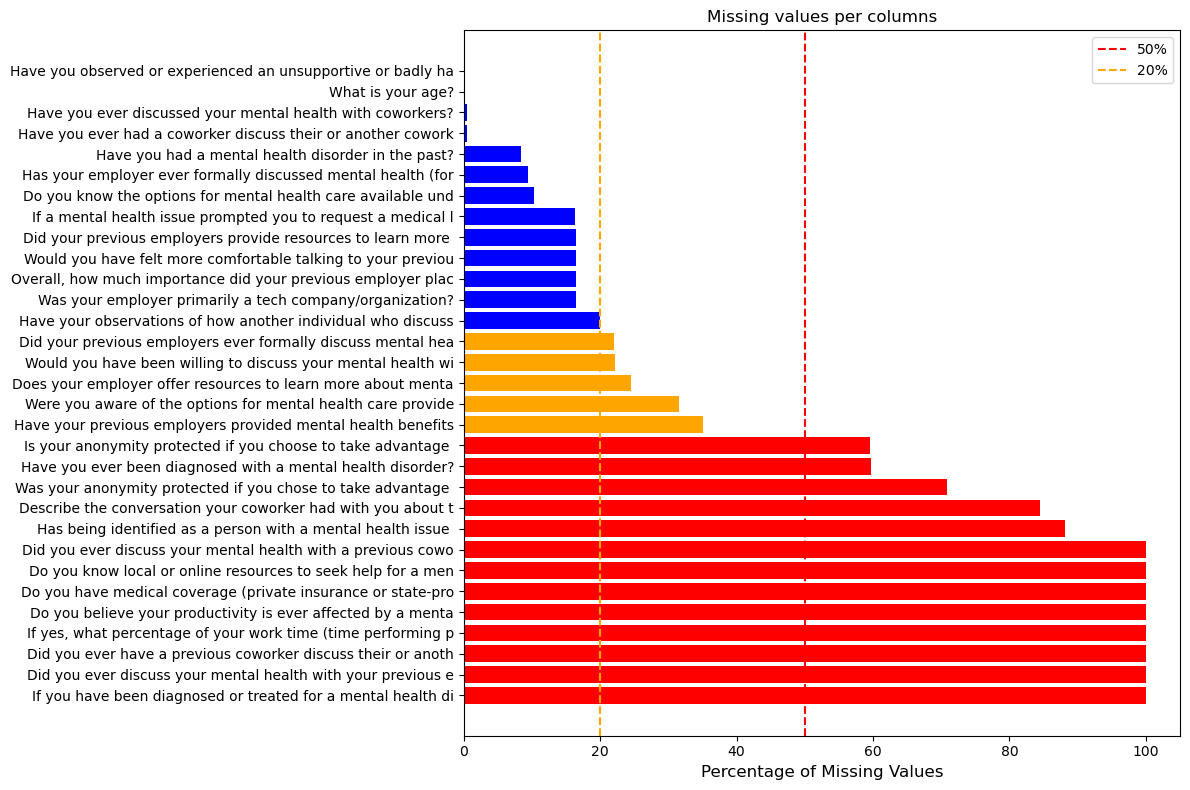

In [317]:
import matplotlib.pyplot as plt

# calculate missing percenteg per column
missing = (df_employed.isna().sum() / len(df_employed) * 100)
missing = missing[missing > 0].sort_values(ascending =False)

print(f"Columns with missing values: {len(missing)} out of {df_employed.shape[1]}")
print(f"\nTop 10 most missing:")
print(missing.head(10).round(2))

# Plot
plt.figure(figsize=(12,8))
colors =[ 'red' if x > 50 else 'orange' if x > 20 else 'blue' for x in missing.values]
plt.barh(missing.index.str[:60],
missing.values, color=colors)
plt.axvline(x=50, color='red', linestyle='--', label='50%')
plt.axvline(x=20, color='orange', linestyle='--', label='20%')
plt.xlabel('Percentage of Missing Values', fontsize=12)
plt.title('Missing values per columns')
plt.legend()
plt.tight_layout()
plt.show()

### Missing values analysis
The high number of missign values is expected and has to main reasons:
1. Survey questiosn changed across year. Not all questions were asked in every survey year. A question introduced in 2019 will show 100% missing for 2017-2018 data. this is structural missingness, not data quality issues.
2. Dataset will be split into 3 periods
the dataset will later be split into:
- Pre-COVID (2017-2018)
- During-COVID (2020-2021)
- Post-COVID (2022)

Many columns that appear 100% missing is the combined dataset may have compelte data within a specific period. Therefore, missing values decisions will be revaluated after split in Phase 3.

In [318]:
# Missing values per column per year
# check missing % per column per year
missing_by_year = df_employed.groupby('survey_year').apply(lambda x: x.isna().sum() / len(x) * 100).T
# Transpose so columns are year, rows are questions.

# Round for readability
missing_by_year = missing_by_year.round(1)
# Show only columns that have any missing values
missing_by_year = missing_by_year[missing_by_year.max(axis=1) > 0]

# Sort by total missing
missing_by_year['mean'] = missing_by_year.mean(axis=1)
missing_by_year = missing_by_year.sort_values('mean', ascending=False)
missing_by_year = missing_by_year.drop(columns=['mean'])

print(f"Columns with missing values per year:")
print(missing_by_year)

Columns with missing values per year:
survey_year                                          2017   2018   2019  \
If you have been diagnosed or treated for a men...  100.0  100.0  100.0   
If you have been diagnosed or treated for a men...  100.0  100.0  100.0   
Did you ever discuss your mental health with yo...  100.0  100.0  100.0   
Did you ever have a previous coworker discuss t...  100.0  100.0  100.0   
If yes, what percentage of your work time (time...  100.0  100.0  100.0   
Did you ever discuss your mental health with a ...  100.0  100.0  100.0   
Do you believe your productivity is ever affect...  100.0  100.0  100.0   
Do you have medical coverage (private insurance...  100.0  100.0  100.0   
Do you know local or online resources to seek h...  100.0  100.0  100.0   
Has being identified as a person with a mental ...   89.3   87.0   86.5   
Describe the conversation your coworker had wit...   84.8   83.1   82.9   
Was your anonymity protected if you chose to ta...   71.2   69

C:\Users\Tommaso\AppData\Local\Temp\ipykernel_13476\3139271736.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_year = df_employed.groupby('survey_year').apply(lambda x: x.isna().sum() / len(x) * 100).T


Missing values were analysind per survey years to identify conditional questions and variable with high missingness. Only variable with at least one missing values were displayed in the summary table, this allows me to easly identifie problematic questions.

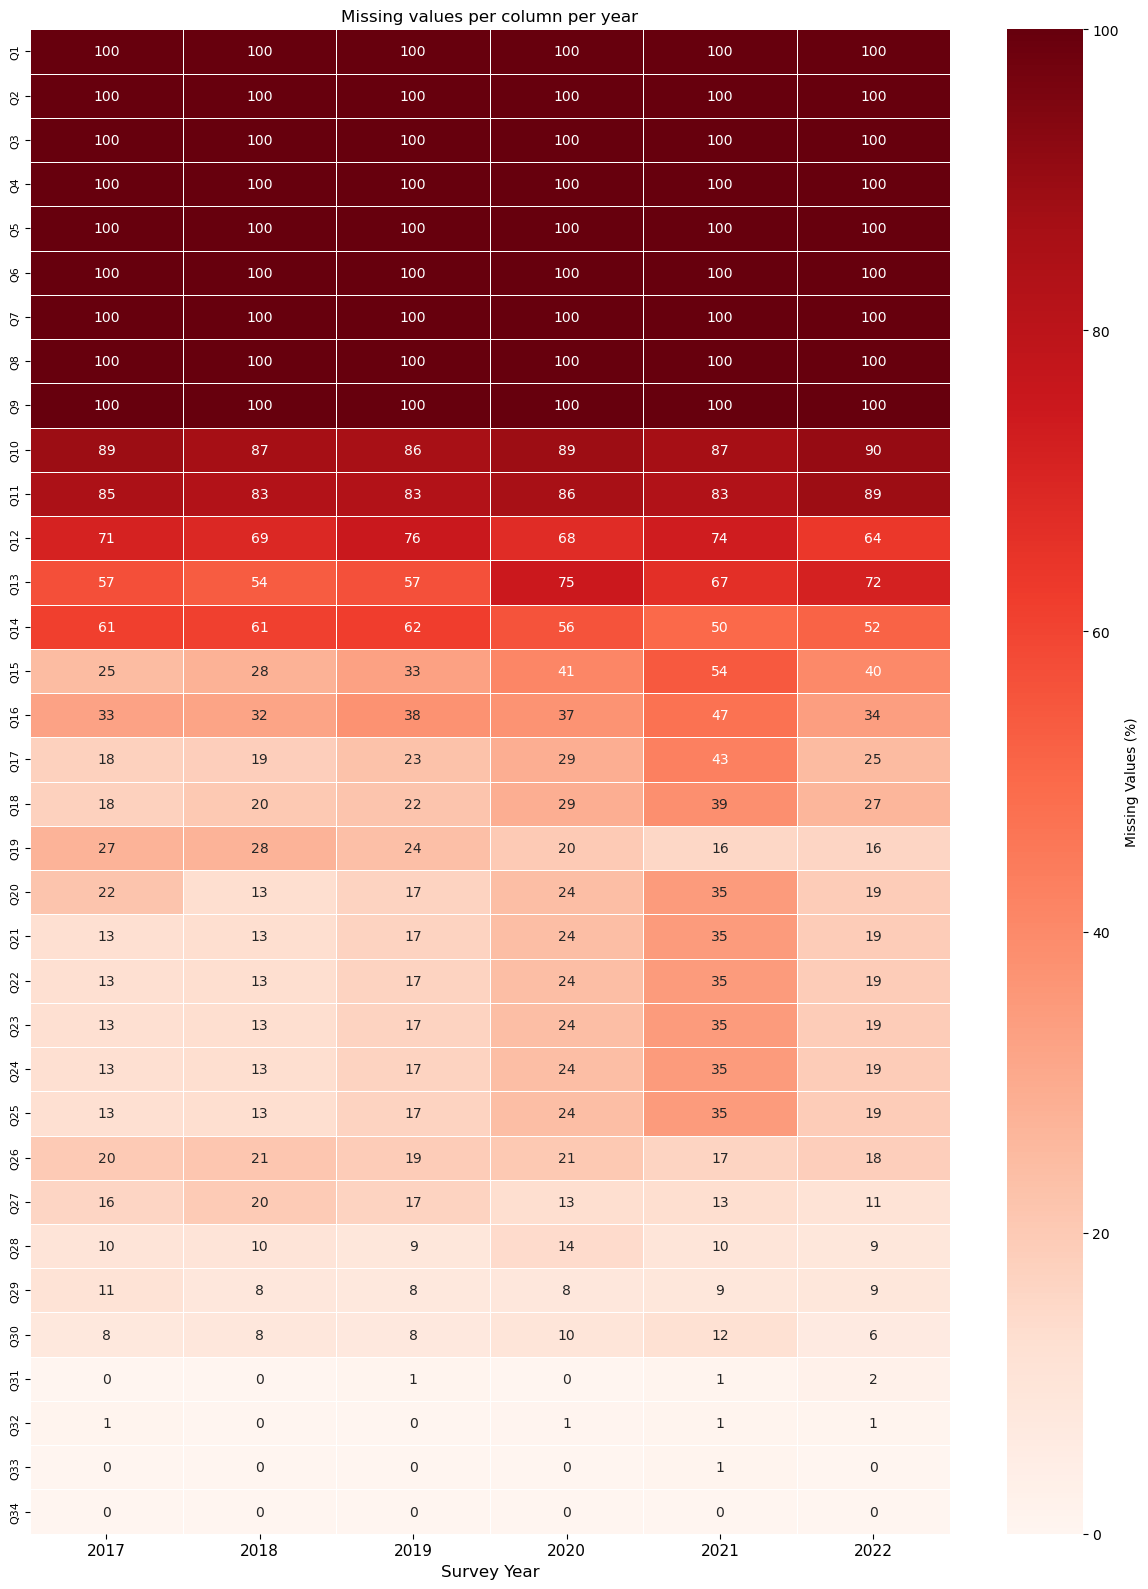

In [319]:
import seaborn as sns

# createa a mapping
question_map = {f"Q{i+1}" : col for i, col in enumerate(missing_by_year.index)}

missing_by_year_plot = missing_by_year.copy()
missing_by_year_plot.index = [f"Q{i+1}" for i in range(len(missing_by_year))]

# Heatmap of missing values per column per year
plt.figure(figsize = (12,16))
sns.heatmap(missing_by_year_plot, cmap='Reds', # 'Reds' colormap for red shades
            annot=True,  # show numbers inside cells
            fmt='.0f', # format as integre no decimal
            linewidths=0.5, vmin=0, # min value for color scale
            vmax=100, # max value for color scale
            cbar_kws={'label': 'Missing Values (%)'}
            )
plt.xlabel('Survey Year', fontsize=12)
plt.title('Missing values per column per year')
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

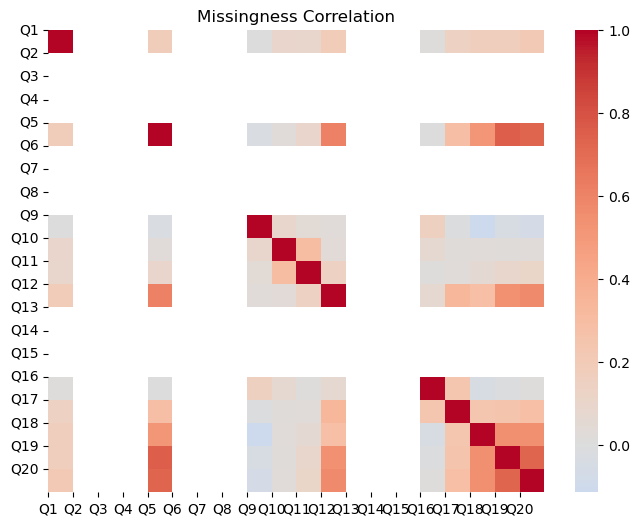

In [320]:
import matplotlib.pyplot as plt

high_missing_cols = df_employed.columns[df_employed.isna().mean() > 0.2]

missing_corr_subset = df_employed[high_missing_cols].isna().astype(int).corr()

short_labels = [f"Q{i+1}" for i in range(len(missing_corr_subset.columns))]

plt.figure(figsize=(8,6))
sns.heatmap(missing_corr_subset, cmap="coolwarm", center=0)

plt.xticks(range(len(short_labels)), short_labels, rotation=0)
plt.yticks(range(len(short_labels)), short_labels)

plt.title("Missingness Correlation")
plt.show()

To better understand the structure of missing values, I created a correlation map only for variable with more then 20% missing data. This allowed me to identifie correlation between survey questions.

### Drop High-Missing Columns

Columns with >50% missing data are not reliable for analysis.
These are typically conditional questions. I drop them.

In [321]:
threshold = 50  # percent

missing = (df_employed.isna().sum() / len(df_employed) * 100)

cols_to_drop = missing[missing > threshold].index.tolist()

# Never drop survey_year
cols_to_drop = [c for c in cols_to_drop if c != 'survey_year']

print(f"\nDropping {len(cols_to_drop)} columns with >{threshold}% missing:")
for c in cols_to_drop:
    print(f"  - {c[:70]}")

df_clean = df_employed.drop(columns=cols_to_drop, errors='ignore')
print(f"\nDataset after dropping: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")



Dropping 14 columns with >50% missing:
  - Describe the conversation your coworker had with you about their menta
  - Did you ever discuss your mental health with a previous coworker(s)?
  - Did you ever discuss your mental health with your previous employer?
  - Did you ever have a previous coworker discuss their or another coworke
  - Do you believe your productivity is ever affected by a mental health i
  - Do you have medical coverage (private insurance or state-provided) tha
  - Do you know local or online resources to seek help for a mental health
  - Has being identified as a person with a mental health issue affected y
  - Have you ever been diagnosed with a mental health disorder?
  - If yes, what percentage of your work time (time performing primary or 
  - If you have been diagnosed or treated for a mental health disorder, do
  - If you have been diagnosed or treated for a mental health disorder, do
  - Is your anonymity protected if you choose to take advantage of mental 


These variables where removed from the analysis as questions were conditional and only shows to a subset of respondents. As these variables contains insufficient information for the majority of repsondets, including them could introduce noise adn bias into the clustering analysis.

In [322]:
print(df_clean.columns.tolist())

['Are you openly identified at work as a person with a mental health issue?', 'Are you self-employed?', 'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?', 'Did your previous employers provide resources to learn more about mental health disorders and how to seek help?', 'Do you currently have a mental health disorder?', 'Do you have a family history of mental illness?', 'Do you have previous employers?', 'Do you know the options for mental health care available under your employer-provided health coverage?', 'Does your employer offer resources to learn more about mental health disorders and options for seeking help?', 'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?', 'Have you ever discussed your mental health with coworkers?', 'Have you ever discussed your mental health with your employer?', "Have you ever had a cowork

In [323]:
# Debug

# Check which dataframe I am using
print("Original dataset shape:", df_employed.shape)
print("Clean dataset shape:", df_clean.shape)

missing_check = (df_clean.isna().mean() * 100)

print("\nColumns with missing values:", (missing_check > 0).sum())
print("\nTop missing columns:")
print(missing_check.sort_values(ascending=False).head(10).round(2))

Original dataset shape: (1701, 58)
Clean dataset shape: (1701, 44)

Columns with missing values: 20

Top missing columns:
Have your previous employers provided mental health benefits?                                                                                                                    35.10
Were you aware of the options for mental health care provided by your previous employers?                                                                                        31.57
Does your employer offer resources to learn more about mental health disorders and options for seeking help?                                                                     24.51
Would you have been willing to discuss your mental health with your direct supervisor(s)?                                                                                        22.10
Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?                 

In [324]:
# Verify df_clean after dropping
missing_clean = (df_clean.isna().sum() /len(df_clean) *100)
missing_clean = missing_clean[missing_clean >0].sort_values(ascending=False)

print(f"\ndf_clean: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
print(f"\nColumns still with missing values: {len(missing_clean)}")
print(f"COlumsn still >50% missing: {(missing_clean >50).sum()}")
print(f"Columns still >20% missing: {(missing_clean > 20).sum()}")

print(f"\nRemaining missing values:")
print(missing_clean.round(2).to_string())


df_clean: 1701 rows x 44 columns

Columns still with missing values: 20
COlumsn still >50% missing: 0
Columns still >20% missing: 6

Remaining missing values:
Have your previous employers provided mental health benefits?                                                                                                                    35.10
Were you aware of the options for mental health care provided by your previous employers?                                                                                        31.57
Does your employer offer resources to learn more about mental health disorders and options for seeking help?                                                                     24.51
Would you have been willing to discuss your mental health with your direct supervisor(s)?                                                                                        22.10
Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other off

After removing varaible with more then 50% missing values, the dataset contians 44 features. While some variables still contain missing responses which is common is survey data. The remaining features contain sufficient infomation for the analysis.

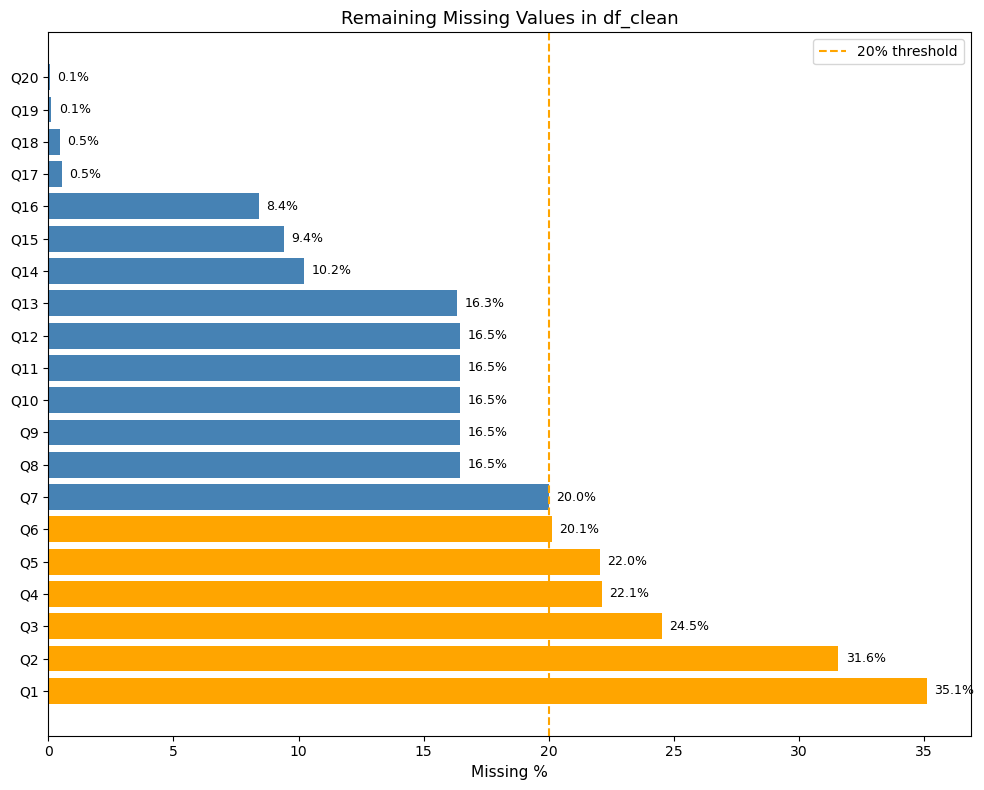


Question Legend:
------------------------------------------------------------
Q01 -> Have your previous employers provided mental health benefits?
Q02 -> Were you aware of the options for mental health care provided by your 
Q03 -> Does your employer offer resources to learn more about mental health d
Q04 -> Would you have been willing to discuss your mental health with your di
Q05 -> Did your previous employers ever formally discuss mental health (as pa
Q06 -> Would you have been willing to discuss your mental health with your co
Q07 -> Have your observations of how another individual who discussed a menta
Q08 -> Did your previous employers provide resources to learn more about ment
Q09 -> Overall, how much importance did your previous employer place on menta
Q10 -> Overall, how much importance did your previous employer place on physi
Q11 -> Was your employer primarily a tech company/organization?
Q12 -> Would you have felt more comfortable talking to your previous employer
Q13 -> I

In [325]:
from matplotlib.lines import lineStyles
# Visualise remaining missing values in df_clean

# Recalculate on df_clean
missing_clean = (df_clean.isna().sum() / len(df_clean) * 100)
missing_clean = missing_clean[missing_clean > 0].sort_values(ascending=False)

# Short codes for readability
labels = [f"Q{i+1}" for i in range(len(missing_clean))]

# Colors based on threshold
colors = ['orange' if x > 20 else 'steelblue' for x in missing_clean.values]

plt.figure(figsize=(10, 8))
bars = plt.barh(labels, missing_clean.values, color=colors)

# Add value labels on bars
for bar, val in zip(bars, missing_clean.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.axvline(x=20, color='orange', linestyle='--', label='20% threshold')
plt.xlabel('Missing %', fontsize=11)
plt.title('Remaining Missing Values in df_clean', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Print legend
print("\nQuestion Legend:")
print("-" * 60)
for i, col in enumerate(missing_clean.index):
    print(f"Q{i+1:02d} -> {col[:70]}")

### Impute Missing Values

For remaining columns with <50% missing:
- Numeric columns: fill with MEDIAN (robust to outliers)
- Categorical columns: fill with MODE (most frequent value)

In [326]:
for col in df_clean.columns:
    if col == 'survey_year':
        continue
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)
        else:
            mode_val = df_clean[col].mode()
            if len(mode_val) > 0:
                df_clean[col] = df_clean[col].fillna(mode_val[0])

remaining_na = df_clean.isnull().sum().sum()
print(f"\nRemaining NA values: {remaining_na}")
print(f"Clean dataset: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")



Remaining NA values: 0
Clean dataset: 1701 rows x 44 columns


Remaining missing values were imputed using simple statistical methods. Numeric variables were filled using median, while categorical variables were imputed using the most frequent valus. Give that the remaining missing percentages were low, this approach was considered without significantly change the underlying distribution.

In [327]:
# Verify
still_missing = df_clean.isnull().sum()
still_missing = still_missing[still_missing >0]

if len(still_missing) == 0:
  print("No missing values left!")
else:
  print("Still missing values: {len(still_missing)}")

No missing values left!


### Encode Gender

Gender is a NOMINAL variable (no natural order).
I use ONE-HOT encoding: create separate 0/1 columns for each category.

In [328]:
# Check gender values before encoding
print("Gender unique values:")
print(df_clean['What is your gender?'].value_counts())

print(f"\nMissing: {df_clean['What is your gender?'].isnull().sum()}")

Gender unique values:
What is your gender?
Male                 1084
Female                500
Other/Non-binary       97
Prefer not to say      20
Name: count, dtype: int64

Missing: 0


In [329]:
gender_col = "What is your gender?"

# Check if already encoded
if gender_col in df_clean.columns:
    gender_dummies = pd.get_dummies(df_clean[gender_col], prefix='gender')
    df_clean = pd.concat([df_clean.drop(columns=[gender_col]),
                          gender_dummies], axis=1)
    print("Gender encoded! New columns:")
    for col in gender_dummies.columns:
        print(f"  - {col}: {df_clean[col].sum():.0f} people")
else:
    print("Gender already encoded! Skipping.")
    print("Existing gender columns:")
    for col in [c for c in df_clean.columns if 'gender' in c.lower()]:
        print(f"  - {col}: {df_clean[col].sum():.0f} people")

print(f"\ndf_clean shape: {df_clean.shape}")

Gender encoded! New columns:
  - gender_Female: 500 people
  - gender_Male: 1084 people
  - gender_Other/Non-binary: 97 people
  - gender_Prefer not to say: 20 people

df_clean shape: (1701, 47)


During the final review of the cleaned dataset, I notice that the gender field generated via one-hot encoding, still contained Boolean values (True/False) instead of integers.

In [330]:
# FIX: convert gender columns from True/False to 1/0
gender_cols = [c for c in df_clean.columns if 'gender' in c.lower()]
if gender_cols:
  for col in gender_cols:
    df_clean[col] = df_clean[col].map(
        {True: 1, False: 0, 'True': 1, 'False':0}
    ).fillna(0).astype(int)
  print("Gender columns fixed (True/False -> 1/0):")
for col in gender_cols:
      print(f" {col}: {df_clean[col].sum():.0f} people")

remaining_na =df_clean.isnull().sum().sum()
print(f"\nRemaining NA values: {remaining_na}")

# Save
clean_csv_path = OUTPUT_PATH + "/osmi_clean_2017_2022.csv"
df_clean.to_csv(clean_csv_path, index=False)
print(f"\nClean dataset saved to: {clean_csv_path}")

Gender columns fixed (True/False -> 1/0):
 gender_Female: 500 people
 gender_Male: 1084 people
 gender_Other/Non-binary: 97 people
 gender_Prefer not to say: 20 people

Remaining NA values: 0

Clean dataset saved to: output/osmi_clean_2017_2022.csv


### Categorical Answers

In [331]:
df_clean.dtypes[df_clean.dtypes == 'object']

If you have a mental health disorder, how often do you feel that it interferes with your work when NOT being treated effectively (i.e., when you are experiencing symptoms)?    object
If you have a mental health disorder, how often do you feel that it interferes with your work when being treated effectively?                                                   object
covid_period                                                                                                                                                                    object
dtype: object

The two columns:
- If you have a mental health disorder, how often do you feel that it interferes with your work when NOT being treated effectively (i.e., when you are experiencing symptoms)?
- If you have a mental health disorder, how often do you feel that it interferes with your work when being treated effectively?

Contain text categories that are ordered.

The code maps them to integers:

| Text | Number |
| :--- | :---: |
| Never | 0 |
| Rarely | 1 |
| Sometimes | 2 |
| Often | 3 |
| Not Applicable to me | 0 |





In [332]:

freq_map = {
    'Never':0,
    'Rarely':1,
    'Sometimes':2,
    'Often':3,
    'Not applicable to me': 0
}
col_not_treated = "If you have a mental health disorder, how often do you feel that it interferes with your work when NOT being treated effectively (i.e., when you are experiencing symptoms)?"
col_treated = "If you have a mental health disorder, how often do you feel that it interferes with your work when being treated effectively?"

df_clean[col_not_treated] = df_clean[col_not_treated].map(freq_map)
df_clean[col_treated] = df_clean[col_treated].map(freq_map)

# Force numeric dtypes
df_clean[col_not_treated] = pd.to_numeric(df_clean[col_not_treated],errors='coerce')
df_clean[col_treated] = pd.to_numeric(df_clean[col_treated],errors='coerce')

# Handle NaN after mapping using median
df_clean[col_not_treated] = df_clean[col_not_treated].fillna(0)
df_clean[col_treated] = df_clean[col_treated].fillna(0)

# Verify
print(df_clean[[col_not_treated, col_treated]].head(10))
print(df_clean[[col_not_treated, col_treated]].dtypes)
print("Remaining NaN values:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Save to a new file
df_clean.to_csv("osmi_clean_2017_2022_encoded.csv", index=False)
print("File saved")

    If you have a mental health disorder, how often do you feel that it interferes with your work when NOT being treated effectively (i.e., when you are experiencing symptoms)?  \
0                                                   2                                                                                                                              
1                                                   2                                                                                                                              
2                                                   2                                                                                                                              
3                                                   3                                                                                                                              
5                                                   0                                               

Starting from the cleaned dataset df_clean,I have applied an ordinal encoding to the two questions about how oftern a mental health disorder interferes with work. The categorical answers were mapped to numeric values, with "Not applicable to me" treated as 0. I then converted these columns to integer type and replaced any remaining missing values with 0, obtaining fully numeric features suitable for UMAP and clustering.

In [333]:
df_clean = pd.read_csv("osmi_clean_2017_2022_encoded.csv")
print(df_clean[[col_not_treated, col_treated]].dtypes)

If you have a mental health disorder, how often do you feel that it interferes with your work when NOT being treated effectively (i.e., when you are experiencing symptoms)?    int64
If you have a mental health disorder, how often do you feel that it interferes with your work when being treated effectively?                                                   int64
dtype: object


### Final Clean Dataset Summary

In [334]:
df_master = df_clean.copy()

print("\nFINAL CLEAN DATASET")
print(f"Rows: {df_master.shape[0]}")
print(f"Columns: {df_master.shape[1]}")
print(f"Missing: {df_master.isnull().sum().sum()}")

print(f"\nYear distribution:")
print(df_master['survey_year'].value_counts().sort_index())

print(f"\nGender distribution:")
for col in [c for c in df_master.columns if 'gender' in c.lower()]:
  print(f" {col}: {df_master[col].sum(): .0f}")

# Save clean dataset
clean_csv_path = OUTPUT_PATH + "/osmi_MASTER_2017_2022.csv"
df_master.to_csv(clean_csv_path, index=False)
print(f"\nClean dataset saved to: {clean_csv_path}")


FINAL CLEAN DATASET
Rows: 1701
Columns: 47
Missing: 0

Year distribution:
survey_year
2017    643
2018    361
2019    304
2020    155
2021    114
2022    124
Name: count, dtype: int64

Gender distribution:
 gender_Female:  500
 gender_Male:  1084
 gender_Other/Non-binary:  97
 gender_Prefer not to say:  20

Clean dataset saved to: output/osmi_MASTER_2017_2022.csv


The dataset  df_master is now fully numeric and contains no missing values. df_master is ready for analysis-

# Phase 3: Exploratory Data Analysis (EDA)

In this phase, I perform Exploratory Data Analysis on the cleaned dataset (df_master)
The goal is to build a good understanding of the data before applying dimensionality reduction (UMAP) and clustering.

EDA is essential because:
1. Inspect the distribution of key variable
2. Identify potential issues such as outliers, missing vlaues or class imbalances.
3. generate initial insight that will be revisited in the discussion.

### Sample Size Over Time

As a first step, I examine how the sample size evolve over time.
This is important because the number of respondents varies substantially across surveys years, which directly affects the statistical power of the analysis and the stability of any clustering results.

By graphically rapresenting the number of interviewees per year, I can:
1. Check whether some years are under-rapresented.
2. Understand whether the dataset is dominated by specific periods.
3. Transparently report these limitations in the methodology and resurlts sections.

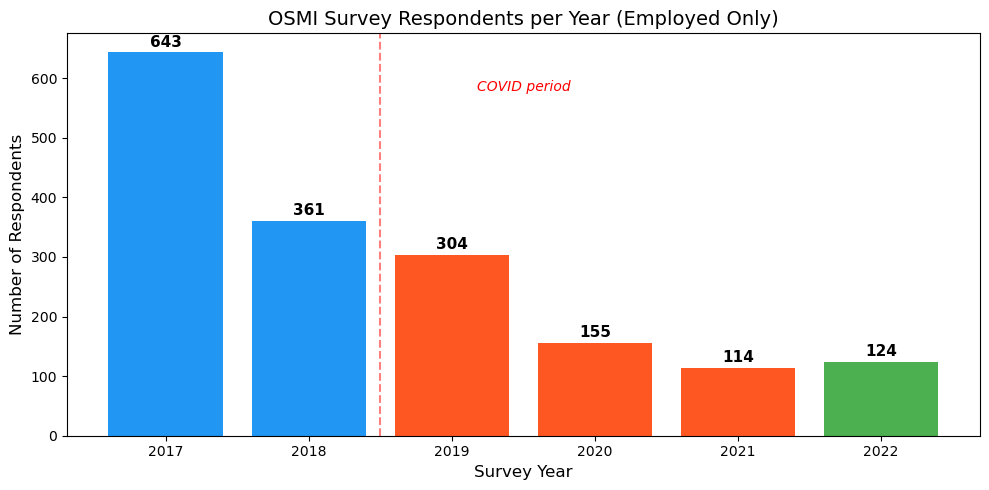

Saved: 01_respondents_per_year.png


In [335]:
fig, ax = plt.subplots(figsize=(10, 5))
year_counts = df_master['survey_year'].value_counts().sort_index()
bars = ax.bar(year_counts.index.astype(str), year_counts.values,
              color=['#2196F3', '#2196F3', '#FF5722', '#FF5722', '#FF5722', '#4CAF50'])
ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_title('OSMI Survey Respondents per Year (Employed Only)', fontsize=14)

# Add count labels on bars
for bar, count in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add COVID period annotation
ax.axvline(x=1.5, color='red', linestyle='--', alpha=0.5)
ax.text(2.5, max(year_counts.values)*0.9, 'COVID period',
        ha='center', fontsize=10, color='red', style='italic')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/01_respondents_per_year.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_respondents_per_year.png")

The plot shows that the number of repsondents is not constant over time. In particular, there is a visible drop in participation during the COVID period. This is quite intuitive: many employees were working from home, work routines changed a lot, and people were probably less available or less motivated to complete a survey about mental health at work. Because of this, the results for those years are based on a smaller sample, so I try not to over-interpret year by year differences and focus more on the general patterns across all years.

### Age Distribution

Before looking at mental health patterns, it is useful to understand who is in the sample in terms of age. In this section I first plot the overall age distribution of respondents and then check how it looks by survey year. This helps to confirm that the dataset mainly covers working-age adults and that there are no major shifts in age composition across years that could bias the later comparisons.

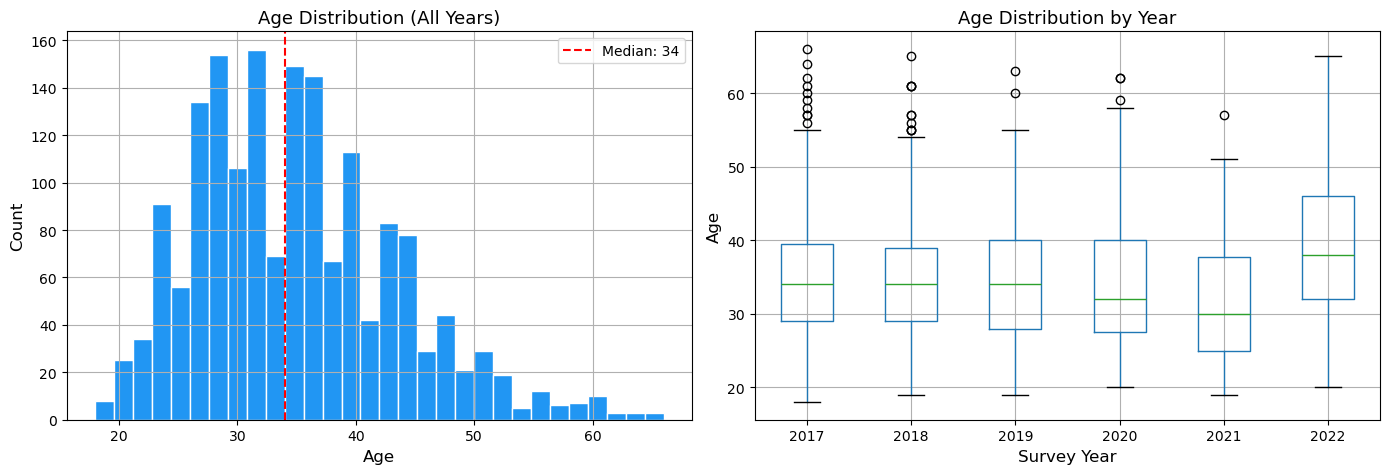

Saved: 02_age_distribution.png


In [336]:
age_col = "What is your age?"
if age_col in df_master.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall distribution
    df_master[age_col].hist(bins=30, ax=axes[0], color='#2196F3', edgecolor='white')
    axes[0].set_xlabel('Age', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Age Distribution (All Years)', fontsize=13)
    axes[0].axvline(df_master[age_col].median(), color='red', linestyle='--',
                     label=f'Median: {df_master[age_col].median():.0f}')
    axes[0].legend()

    # By year (boxplot)
    df_master.boxplot(column=age_col, by='survey_year', ax=axes[1])
    axes[1].set_xlabel('Survey Year', fontsize=12)
    axes[1].set_ylabel('Age', fontsize=12)
    axes[1].set_title('Age Distribution by Year', fontsize=13)
    plt.suptitle('')  # Remove the main title

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + "/02_age_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: 02_age_distribution.png")

Most respondents are in a normal working-age range, with a median age of about 34. The boxplots by year look quite similar, which means the age profile of the sample doesn't change much across survey waves. So any differences between years are probably not just because one year had "younger" or "older" people.

### Mental Health Disorder Prevalence Over Time

Here I look at how self-reported mental health disorders change across survey years. The idea is to see whether the share of respondents who say they curerntly have a mental health disorder is different before, during, and after the COVID-19 period. This helps connect the OSMI data directly to the main research question about how technology driven work and the pandemic relate to mental health in tech.

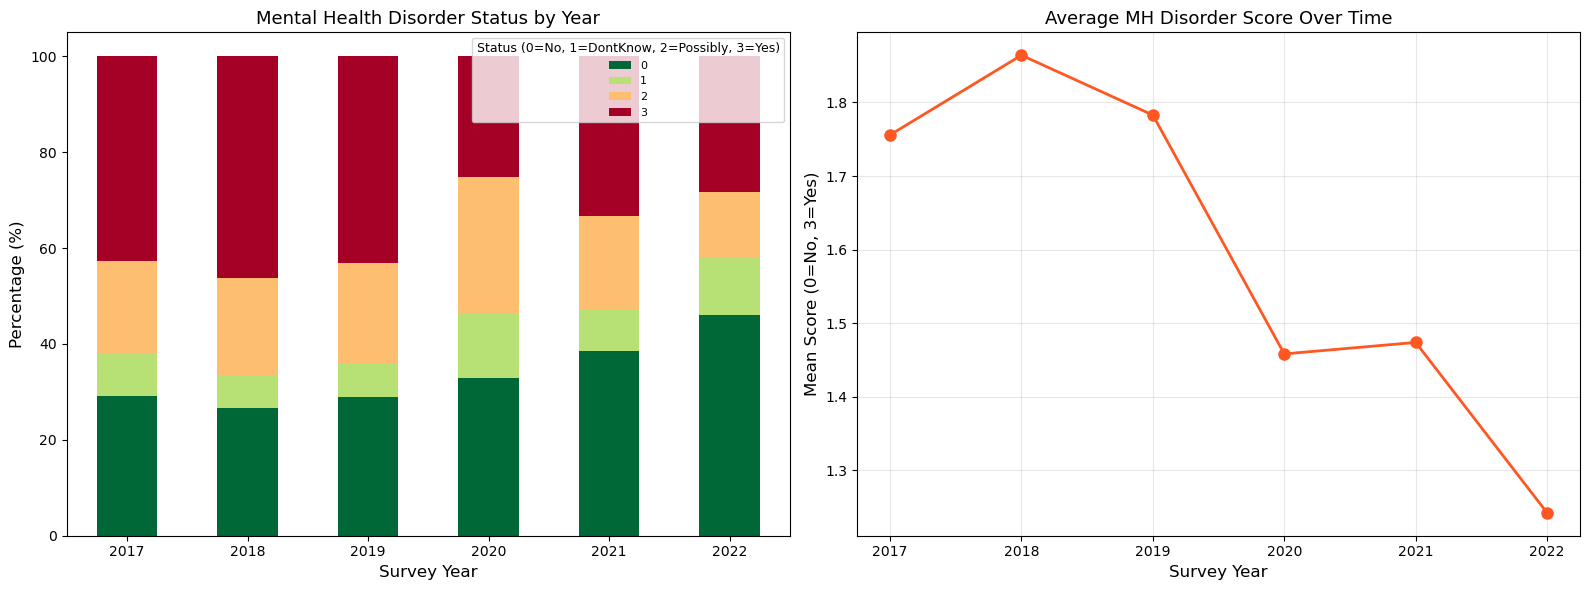

Saved: 03_mh_prevalence_over_time.png


In [337]:
mh_col = "Do you currently have a mental health disorder?"
if mh_col in df_master.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Stacked bar chart per year
    mh_by_year = pd.crosstab(df_master['survey_year'], df_master[mh_col], normalize='index') * 100
    mh_by_year.plot(kind='bar', stacked=True, ax=axes[0],
                     colormap='RdYlGn_r')
    axes[0].set_xlabel('Survey Year', fontsize=12)
    axes[0].set_ylabel('Percentage (%)', fontsize=12)
    axes[0].set_title('Mental Health Disorder Status by Year', fontsize=13)
    axes[0].legend(title='Status (0=No, 1=DontKnow, 2=Possibly, 3=Yes)',
                    fontsize=8, title_fontsize=9)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

    # Mean score over time
    mh_mean = df_master.groupby('survey_year')[mh_col].mean()
    axes[1].plot(mh_mean.index, mh_mean.values, 'o-', color='#FF5722',
                  linewidth=2, markersize=8)
    axes[1].set_xlabel('Survey Year', fontsize=12)
    axes[1].set_ylabel('Mean Score (0=No, 3=Yes)', fontsize=12)
    axes[1].set_title('Average MH Disorder Score Over Time', fontsize=13)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + "/03_mh_prevalence_over_time.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: 03_mh_prevalence_over_time.png")

When interpreting this trend, it is importanto to keep a few points in mind.

* First, the number of respondents is lower during the COVID years compared to earlier waves, so the estimates for those years are less table and more sensitive to sampling noise.
* Second, during the pandemic many people were working from home, so some classic work-related stressor (commuting, crowded offices, noisy environments) were reduced. This could have made some respondents feel temporarily better and less likely to report that they "currently" have a mental health disorder.

At the same time, remote work also introduced new sources of stress, such as social isolation, blurred boundaris between work and home, and increased anxiety about health and job security. these mixed effects might partly explain why the trend does not simply show a clear increase or decrease, but rather a more complex pattern around the COVID period.

### Employer Mental Health Support Over Time

Here I track how respondents rate their employer's and the tech industry's support for mental health across years. This helps to check whether support increased, stayed the same, or even declined around the COVID-19 period.

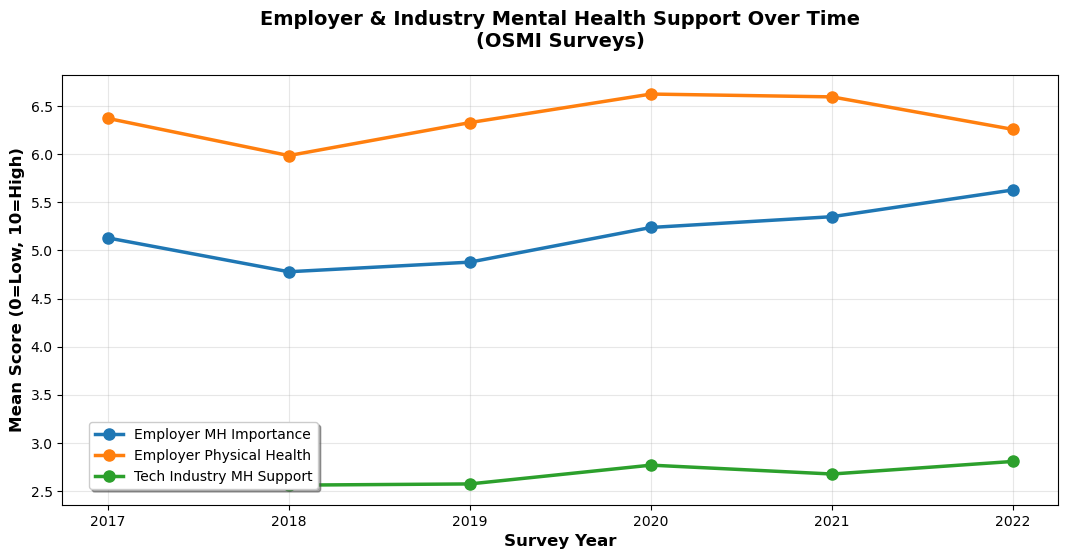

Saved: 04_employer_support_over_time.png


In [338]:
support_cols = [
    "Overall, how much importance does your employer place on mental health?",
    "Overall, how much importance does your employer place on physical health?",
    "Overall, how well do you think the tech industry supports employees with mental health issues?",
]

existing_support = [c for c in support_cols if c in df_master.columns]

if existing_support:
    fig, ax = plt.subplots(figsize=(12, 6))

    for col in existing_support:
        means = df_master.groupby('survey_year')[col].mean()

        # LABEL
        if "mental health" in col.lower() and "employer" in col.lower():
            short_label = "Employer MH Importance"
        elif "physical health" in col.lower():
            short_label = "Employer Physical Health"
        elif "tech industry" in col.lower():
            short_label = "Tech Industry MH Support"
        else:
            short_label = col.split("?")[0][-15:].strip()

        ax.plot(means.index, means.values, 'o-', linewidth=2.5, markersize=8,
                label=short_label)

    ax.set_xlabel('Survey Year', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Score (0=Low, 10=High)', fontsize=12, fontweight='bold')
    ax.set_title('Employer & Industry Mental Health Support Over Time\n(OSMI Surveys)',
                 fontsize=14, fontweight='bold', pad=20)

    # Legend
    ax.legend(fontsize=10, loc='lower left', bbox_to_anchor=(0.02, 0.02),
              frameon=True, shadow=True, ncol=1)

    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=0)

    # Space
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, left=0.12, right=0.95)

    plt.savefig(OUTPUT_PATH + "/04_employer_support_over_time.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: 04_employer_support_over_time.png")


Employer MH importance slowly goes up from 2018 and keeps increasing through
the COVID period, which fits the idea that mental health has become a more
visible topic at work. Physical-health importance peaks around 2020-2021
(when companies were forced to focus on safety and hygiene) and then drops
slightly afterwards. Perceived tech-industry support is lower overall but
shows a small upward trend, consistent with more companies offering remote
work and mental-health resources over time.

### Comfort discussing Mental Health at Work

In this section I look at how comfortable respondents feel talking about mental health at work, distinguishing between direct supervisors and coworkers. This is important because even if employers say they care about mental health, employees might still feel unable to talk about it openly in their day-to-day working relationships.

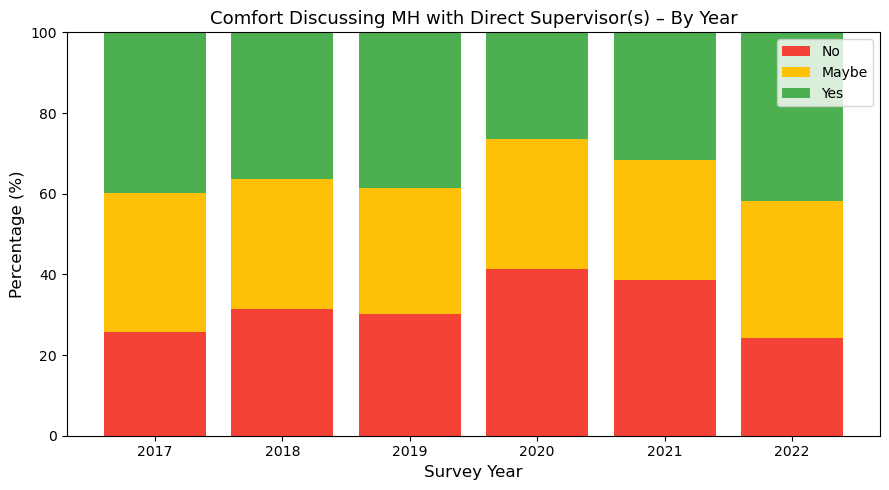

Saved: 05_comfort_supervisor_stacked_by_year.png


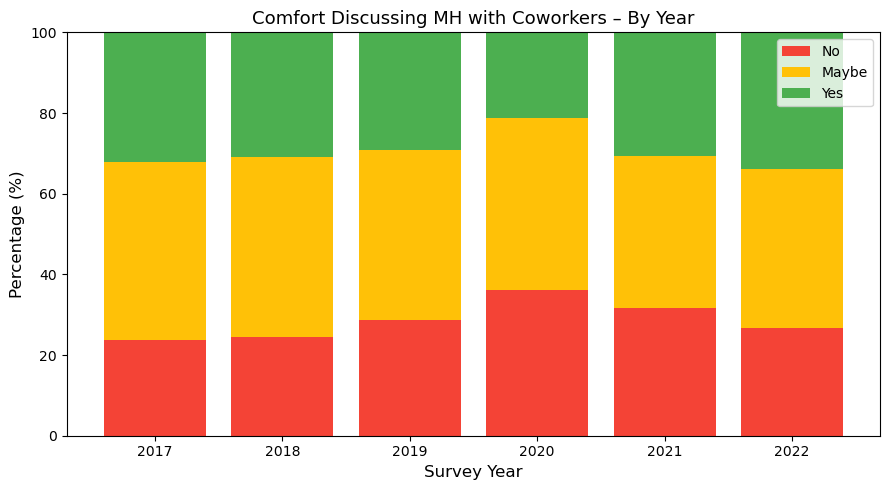

Saved: 06_comfort_coworkers_stacked_by_year.png


In [339]:
sup_col = "Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?"
cow_col = "Would you feel comfortable discussing a mental health issue with your coworkers?"

def plot_comfort_stacked(df, col, title, filename):
    if col not in df.columns:
        print(f"Column '{col}' not found.")
        return

    # Consider only rows with year
    tmp = df.dropna(subset=[col, 'survey_year'])

    # 0=No, 1=Maybe, 2=Yes
    pct_no = tmp.groupby('survey_year')[col].apply(lambda x: (x == 0).mean() * 100)
    pct_maybe = tmp.groupby('survey_year')[col].apply(lambda x: (x == 1).mean() * 100)
    pct_yes = tmp.groupby('survey_year')[col].apply(lambda x: (x == 2).mean() * 100)

    years = pct_no.index

    plt.figure(figsize=(9, 5))
    plt.bar(years, pct_no.values, color='#F44336', label='No')
    plt.bar(years, pct_maybe.values, bottom=pct_no.values,
            color='#FFC107', label='Maybe')
    plt.bar(years, pct_yes.values, bottom=pct_no.values + pct_maybe.values,
            color='#4CAF50', label='Yes')

    plt.xlabel('Survey Year', fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.title(title, fontsize=13)
    plt.xticks(years)
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + f"/{filename}", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

# Graph 1: Supervisor
plot_comfort_stacked(
    df_master,
    sup_col,
    "Comfort Discussing MH with Direct Supervisor(s) – By Year",
    "05_comfort_supervisor_stacked_by_year.png"
)

# Graph 2: Coworkers
plot_comfort_stacked(
    df_master,
    cow_col,
    "Comfort Discussing MH with Coworkers – By Year",
    "06_comfort_coworkers_stacked_by_year.png"
)

The stacked bar charts show that comfort levels do not change dramatically across survey years. For both questions, the proportions of “No”, “Maybe” and “Yes” are relatively stable from 2017 to 2022, with only small year-to-year fluctuations. This suggests that, at least in this sample, openness about mental health at work has evolved slowly rather than through a sudden shift in a specific year.

The main difference is between supervisors and coworkers. In every year, the share of explicit “No” answers is higher for direct supervisors than for coworkers, while “Yes” is more frequent in the coworker chart. In other words, respondents consistently feel more comfortable talking about mental health with peers than with their manager. This points to a persistent gap between informal support among colleagues and formal conversations with those in a position of authority, even as awareness of mental health in tech has increased over time.

### Employer Mental health importance by company size

In this step I examine whether perceived employer support for mental health differs by company size. The idea is that larger organisations may have more formal HR structures and resources (e.g. EAPs, internal counsellors), while smaller companies might be more informal but have fewer dedicated mental-health programmes. Looking at this relationship is useful because it helps to understand whether the size of the organisation is associated with how much importance employees feel their employer places on mental health.

Company size categories present in data: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]


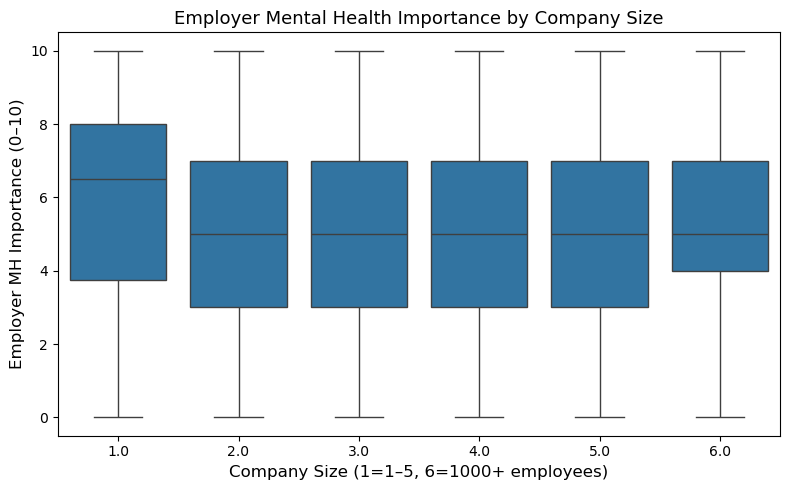

Saved: 0.7_mh_importance_by_company_size.png

Mean employer MH importance by company size:
How many employees does your company or organization have?
1.0    5.575000
2.0    4.824561
3.0    4.963303
4.0    5.165517
5.0    5.041096
6.0    5.139048
Name: Overall, how much importance does your employer place on mental health?, dtype: float64


In [340]:
size_col = "How many employees does your company or organization have?"
imp_col = "Overall, how much importance does your employer place on mental health?"

if size_col in df_master.columns and imp_col in df_master.columns:

    tmp = df_master[[size_col, imp_col]].dropna()

    # Category order
    size_order = sorted(tmp[size_col].unique())
    print("Company size categories present in data:", size_order)

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=tmp,x=size_col, y=imp_col,order=size_order)

    plt.xlabel('Company Size (1=1–5, 6=1000+ employees)', fontsize=12)
    plt.ylabel('Employer MH Importance (0–10)', fontsize=12)
    plt.title('Employer Mental Health Importance by Company Size', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_PATH + "/07_mh_importance_by_company_size.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: 0.7_mh_importance_by_company_size.png")

    # Means
    means_by_size = tmp.groupby(size_col)[imp_col].mean()
    print("\nMean employer MH importance by company size:")
    print(means_by_size)
else:
    print("One or both columns not found in df_master.")

The boxplot and the mean scores show only small differences in perceived employer mental-health importance across company-size categories. Average scores range roughly between 4.8 and 5.6 on a 0-10 scale, with the smallest companies (1-5 employees) reporting slightly higher values (around 5.6) but no clear monotonic trend as size increases. Overall, this suggests that, in this sample, company size on its own is not strongly associated with how much importance employees feel their employer places on mental health.

A possible explanation is that small and large companies face different trade-offs. In very small teams, working with the same few colleagues every day may reduce some sources of conflict and make relationships more personal, but it can also create a “closed” environment where tensions are harder to escape and negative dynamics are more visible. In contrast, larger organisations usually have more formal HR structures and resources, but at the same time they may feel more anonymous and hierarchical, which can make it harder for employees to feel genuinely supported. These opposite mechanisms can balance out in the aggregate data, leading to only minor average differences between size categories.

 ### Correlation between key mental health variables

In this step I compute a correlation matrix between all numeric variables in the cleaned and encoded dataset. This helps to see which features tend to move together and to identify pairs of variables with stronger linear relationships.

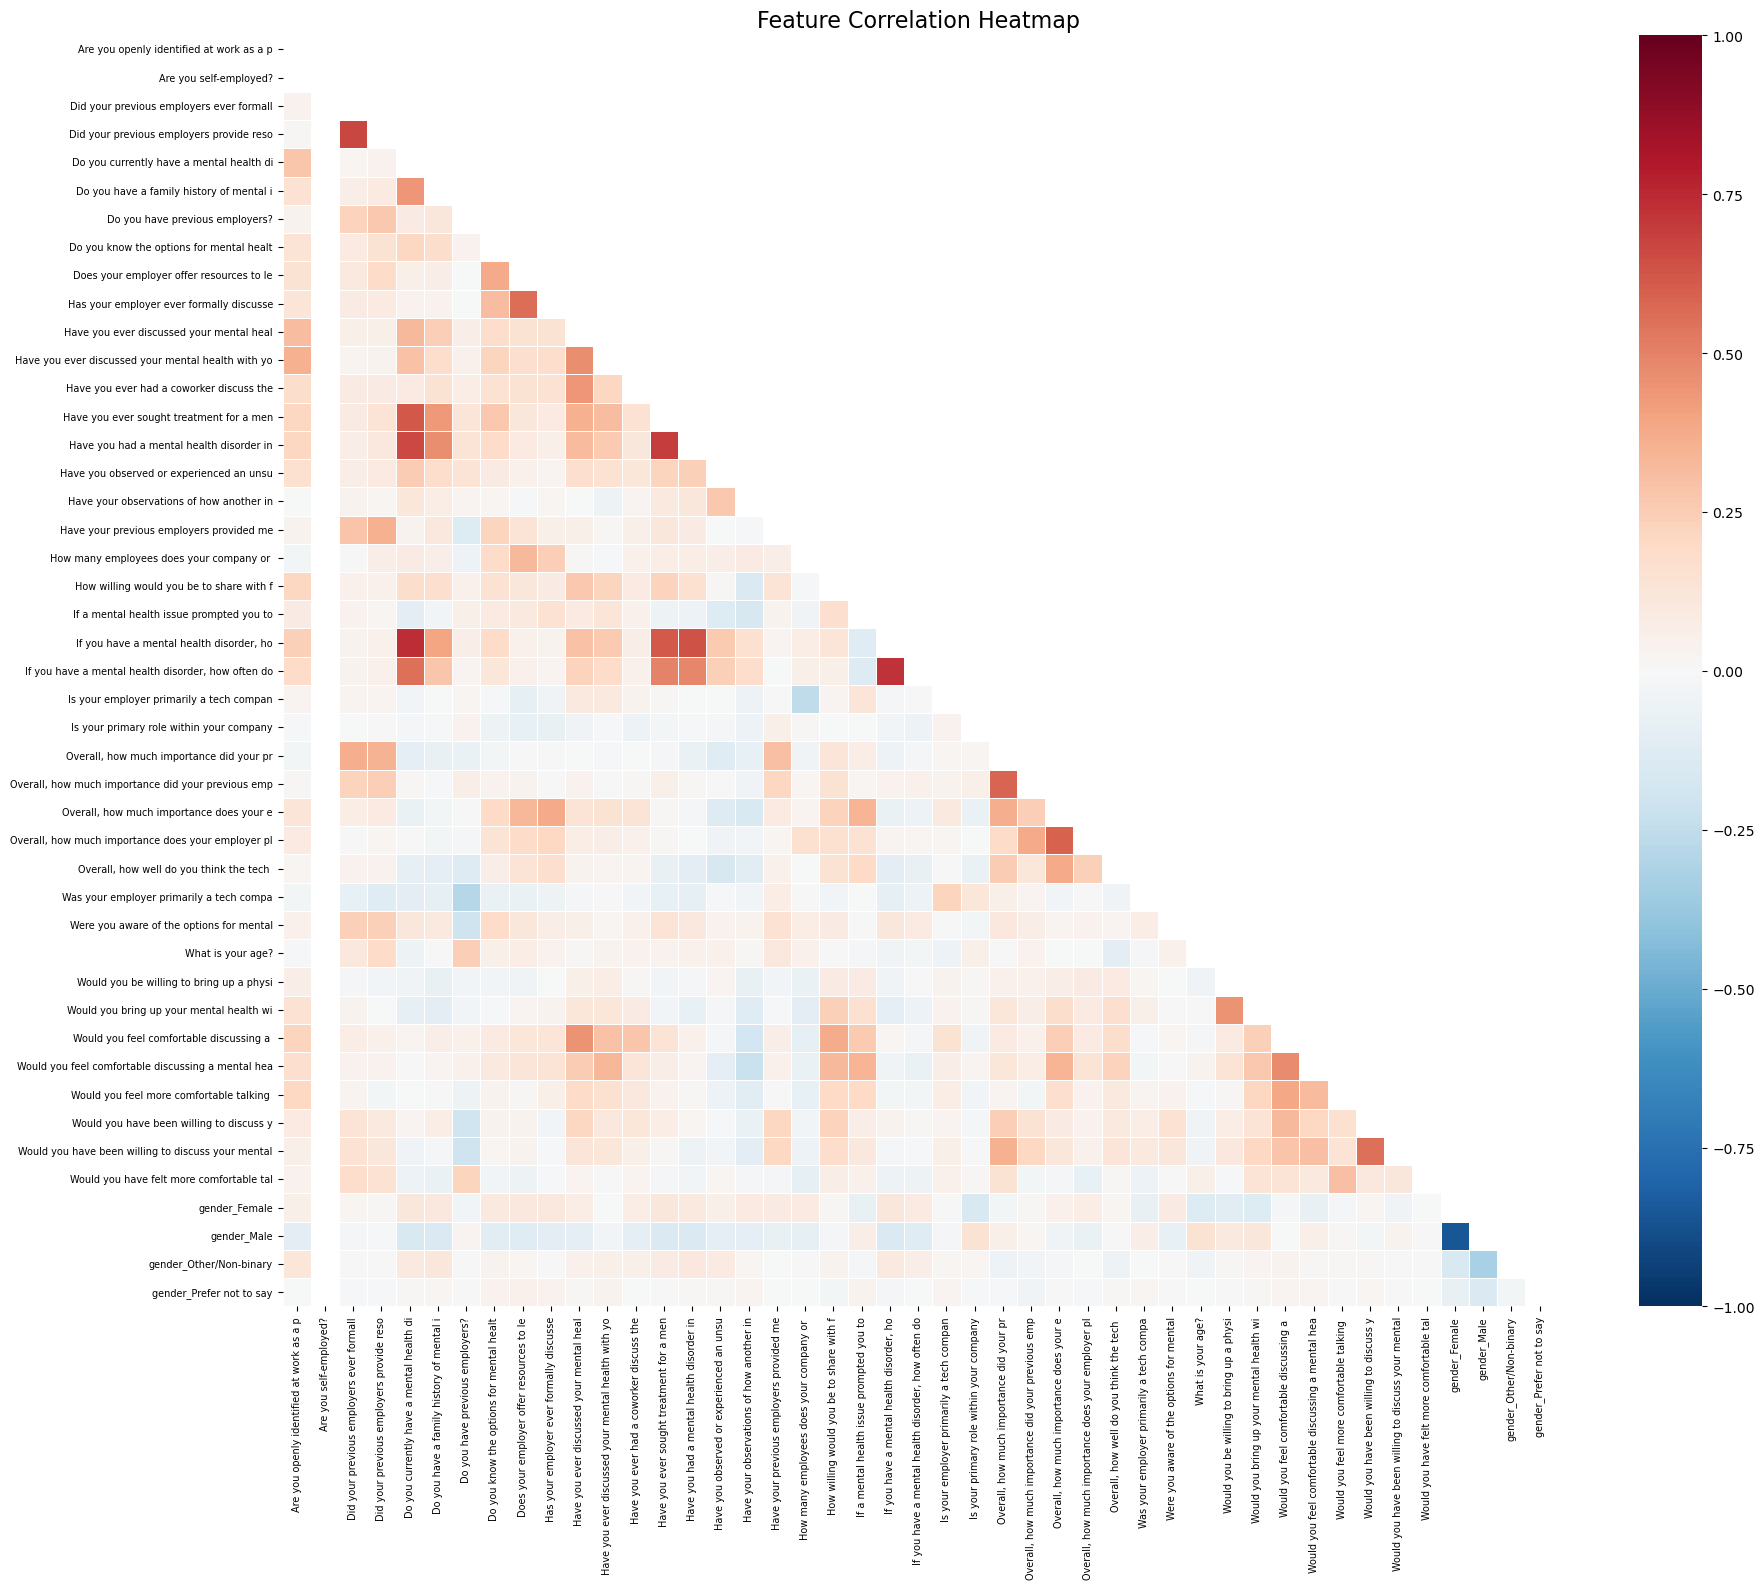

Saved: 08_correlation_heatmap.png

 STRONGEST CORRELATIONS (|r| > 0.3) === 
  r=+0.31: Are you openly identified at work as a p <-> Have you ever discussed your mental heal
  r=+0.35: Are you openly identified at work as a p <-> Have you ever discussed your mental heal
  r=+0.67: Did your previous employers ever formall <-> Did your previous employers provide reso
  r=+0.36: Did your previous employers ever formall <-> Overall, how much importance did your pr
  r=+0.36: Did your previous employers provide reso <-> Have your previous employers provided me
  r=+0.34: Did your previous employers provide reso <-> Overall, how much importance did your pr
  r=+0.44: Do you currently have a mental health di <-> Do you have a family history of mental i
  r=+0.32: Do you currently have a mental health di <-> Have you ever discussed your mental heal
  r=+0.62: Do you currently have a mental health di <-> Have you ever sought treatment for a men
  r=+0.66: Do you currently have a mental health di

In [341]:
# To keep the output readable, I only highlight pairs of variables with an absolute correlation |r| greater than 0.30.
#values around |r| ≈ 0.3 are often interpreted
# as moderate correlations in the social‑science literature, while smaller coefficients are usually considered weak

# Select only numeric columns for correlation
numeric_df = df_master.select_dtypes(include=[np.number])

# Remove survey_year from correlation
if 'survey_year' in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=['survey_year'])

# Shorten column names for readability in the heatmap
short_names = {}
for col in numeric_df.columns:
    short = col[:40]
    if short in short_names.values():
        short = col[:50]
    short_names[col] = short

corr_df = numeric_df.rename(columns=short_names)
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=16)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/08_correlation_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_correlation_heatmap.png")

# Print strongest correlations
print("\n STRONGEST CORRELATIONS (|r| > 0.3) === ")
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            print(f"  r={r:+.2f}: {corr_matrix.columns[i][:40]} <-> {corr_matrix.columns[j][:40]}")

Visually, the heatmap does not show a single uniform pattern but several rectangular “blocks” of stronger correlations. These blocks correspond to groups of items that measure related aspects of the same underlying construct (for example, personal mental-health history and treatment, or different indicators of employer support such as formal discussions and available resources). In contrast, many cells outside these blocks are close to zero, indicating that several variables are only weakly related to each other.

This structure is reassuring, because it suggests that the questionnaire captures a few coherent clusters of concepts, such as mental-health experience, perceived organisational support and comfort discussing mental health , without the variables being completely redundant.

# Phase 4: Dimensionality Reduction

In this phase I reduce the high-dimensional survey data to a lower-dimensional representation to better understand its overall structure and to prepare it for clustering.

The OSMI dataset contains dozens of mental-health related items, employer support indicators and demographic variables. Visualising and clustering respondents directly in this original feature space is not feasible. Therefore, I first construct a purely numeric feature matrix and standardise all variables. I then apply Principal Component Analysis (PCA) to inspect how much variance can be captured by a small number of linear components, and use Uniform Manifold Approximation and Projection (UMAP) as a non-linear technique to obtain a two-dimensional embedding that is more suitable for revealing potential attitude profiles.

The reduced representations from PCA and UMAP are not the final results, but they provide an initial view of the data structure across years and  a compact space on which to run the subsequent clustering analysis in Phase 5.


In [342]:
df_master.dtypes

Are you openly identified at work as a person with a mental health issue?                                                                                                        float64
Are you self-employed?                                                                                                                                                             int64
Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?                                                float64
Did your previous employers provide resources to learn more about mental health disorders and how to seek help?                                                                  float64
Do you currently have a mental health disorder?                                                                                                                                    int64
Do you have a family history of mental illness?                            

In [343]:
df_master.shape

(1701, 47)

### Constructing the feature matrix

Here I extract only cleaned numeric variables from the dataset and build the feature matrix 'x' used for dimensionality reduction and clustering

In [344]:
# Select only numeric columns, excluding 'survey_year'
feature_cols =[
    c for c in df_master.columns
    if c!= 'survey_year' and df_master[c].dtype in ['float64', 'int64', 'int32', 'uint8', 'bool']
]

# build the feature matrix X
X = df_master[feature_cols].copy()

# Store survey year separately
years_labels = df_master['survey_year'].values

# Check
print(f"Feature matrix X: {X.shape[0]} rows x {X.shape[1]} columns")
print("First 10 feature names:")
print(list(X.columns[:5]))

Feature matrix X: 1701 rows x 45 columns
First 10 feature names:
['Are you openly identified at work as a person with a mental health issue?', 'Are you self-employed?', 'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?', 'Did your previous employers provide resources to learn more about mental health disorders and how to seek help?', 'Do you currently have a mental health disorder?']


### Standardising features

The 45 input variables in 'X' are all numeric, but they are measured on different scales. To ensure that no single variable dominates the distance calculations used by PCA, UMAP and K-Means, I standardise all features to have approximately zero mean and unit vatiance using 'StandardScaler'.

In [345]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled Matrix shape: {X_scaled.shape}")
print(f"Mean of first feature : {X_scaled[:,0].mean():.2f}")
print(f"std of first feature: {X_scaled[:,0].std():.2f}")

Scaled Matrix shape: (1701, 45)
Mean of first feature : 0.00
std of first feature: 1.00


### Principal component analysis (PCA)

The master dataset (df_master) contains 45 numeric variables for each respondent, covering mental health status, disclosure attitudes and organisational characteristics. After removing the survey_year identifier and the categorical covid_period label, these 45 variables are collected into a feature matrix X. This matrix is then standardised (zero mean, unit variance per feature) to obtain X_scaled, which is the input on which PCA is applied.

Each respondent can therefore be seen as a point in a 45-dimensional standardised space. Working directly in such a high-dimensional space is difficult: it is impossible to visualise, and many variables are correlated or contain redundant information. Principal Component Analysis (PCA) is used to reduce this high-dimensional representation to a smaller set of orthogonal components while preserving as much variance as possible.

Intuitively, PCA searches for new axes (principal components) that are linear combinations of all original variables in X_scaled and that capture the directions along which respondents differ the most. The first principal component (PC1) explains the largest share of variance in the data, the second component (PC2) explains the largest remaining variance under the constraint of being orthogonal to PC1, and so on.

By examining how much variance is explained by each component and by the cumulative set of components, I can assess how many dimensions are needed to represent most of the information in the data, and obtain low-dimensional projections that provide an interpretable visual overview of the structure of respondents' attitudes over time.


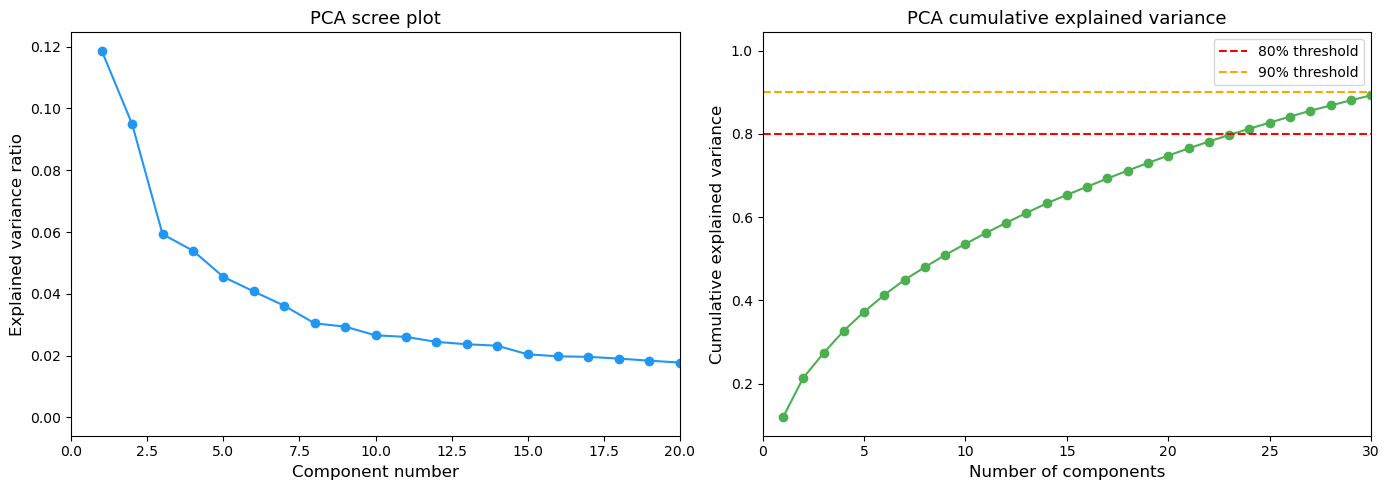

Components needed for 80% variance: 24
Components needed for 90% variance: 31


In [346]:
from sklearn.decomposition import PCA

# Full PCA to inspect explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumvar = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot: explained variance per component
axes[0].plot(
    range(1, len(explained) + 1),
    explained,
    'o-',
    color='#2196F3'
)
axes[0].set_xlabel('Component number', fontsize=12)
axes[0].set_ylabel('Explained variance ratio', fontsize=12)
axes[0].set_title('PCA scree plot', fontsize=13)
axes[0].set_xlim(0, min(20, len(explained)))  # show first 20 components

# Cumulative explained variance
axes[1].plot(
    range(1, len(cumvar) + 1),
    cumvar,
    'o-',
    color='#4CAF50'
)
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of components', fontsize=12)
axes[1].set_ylabel('Cumulative explained variance', fontsize=12)
axes[1].set_title('PCA cumulative explained variance', fontsize=13)
axes[1].set_xlim(0, min(30, len(cumvar)))
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/09_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

# How many components to reach 80% and 90% variance
n_components_80 = np.argmax(cumvar >= 0.80) + 1
n_components_90 = np.argmax(cumvar >= 0.90) + 1
print(f"Components needed for 80% variance: {n_components_80}")
print(f"Components needed for 90% variance: {n_components_90}")

PCA was fitted to the standardised feature matrix `X_scaled`. The resulting scree plot shows a steep decline in explained variance for the first few components, followed by a gradual flattening of the curve. In this dataset, the first principal component (PC1) accounts for roughly 12% of the total variance and the second component (PC2) for about 9%, with subsequent components each explaining progressively smaller proportions.

The cumulative variance plot indicates that approximately 24 components are required to reach 80% of the total variance and around 31 components to reach 90%. This means that mental-health attitudes and workplace factors form a relatively high-dimensional structure: no small set of components is sufficient to summarise most of the variability in responses. For this reason, PCA on `X_scaled` is used here primarily as an exploratory and visualisation tool rather than as a strict dimensionality-reduction step for modelling. In the following phases, clustering is performed on the full set of standardised features, while PCA (and UMAP) provide low-dimensional views that help interpret and communicate the underlying patterns.

In [347]:
# 2D PCA projection
# PCA requires 24 components to explain 80% variance,
# a 2D projection is computed to provide a visual overview of the structure of respondents across survey years.
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print("Explained variace PC1:", pca_2d.explained_variance_ratio_[0])
print("Explained variace PC2:", pca_2d.explained_variance_ratio_[1])

Explained variace PC1: 0.11870844266499146
Explained variace PC2: 0.09494771849168701


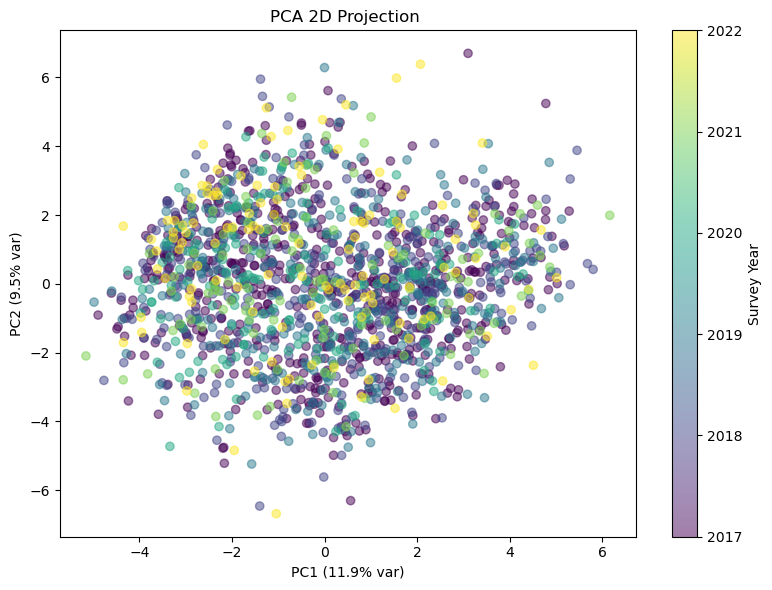

In [348]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=years_labels,
    cmap='viridis',
    alpha=0.5,
)

plt.colorbar(scatter, label='Survey Year')
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA 2D Projection ")
plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/10_2D_PCA.png",
            dpi=150, bbox_inches='tight')
plt.show()

The two-dimensional PCA projection shows that the first principal component explains approximately 11,9% of the total variance, while the second explains 9.5%. Together, the first two components account for 21% of the overall variability in responses.

The visualisation does not reveal clear separation between survey years, indicating that temporal differences are subtle rather then structurally dominant. The substantial overlap suggests that mental health attitudes are distributed across multiple dimensions rather then being driven by a single linear trend over time.

If PC1 explained 60%, it would suggest that multiple survey items load strongly influence a single underlying construct. Conversely, the current 21% indicates that attitudes are fragmented into several related but distinct dimensions.

### DImensionality Reduction UMAP

Uniform Manifold Approximation and Projection (UMAP) is applied to further explore the multidimensional structure of mental health attitudes within the technology workforce.

While Principal Componenet Analysis (PCA) provides a linear projection of variance structure, it may fail to capture non-linear relationships between respondents. Given the attitudinal compelxity of the survey data, non-linear patterns may exist that are not visible ina  purely linear space.

UMAP  it therefore used to:
- Preserve local structure between respondents
- Capture potential non-linear configurations.
- Facilitate visual inspection
- Support subsequent clustering

UMAP was chosen because it preserves local structure in high-dimensional survey data and allows visual identification of latent respondent groups.

c:\Users\Tommaso\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


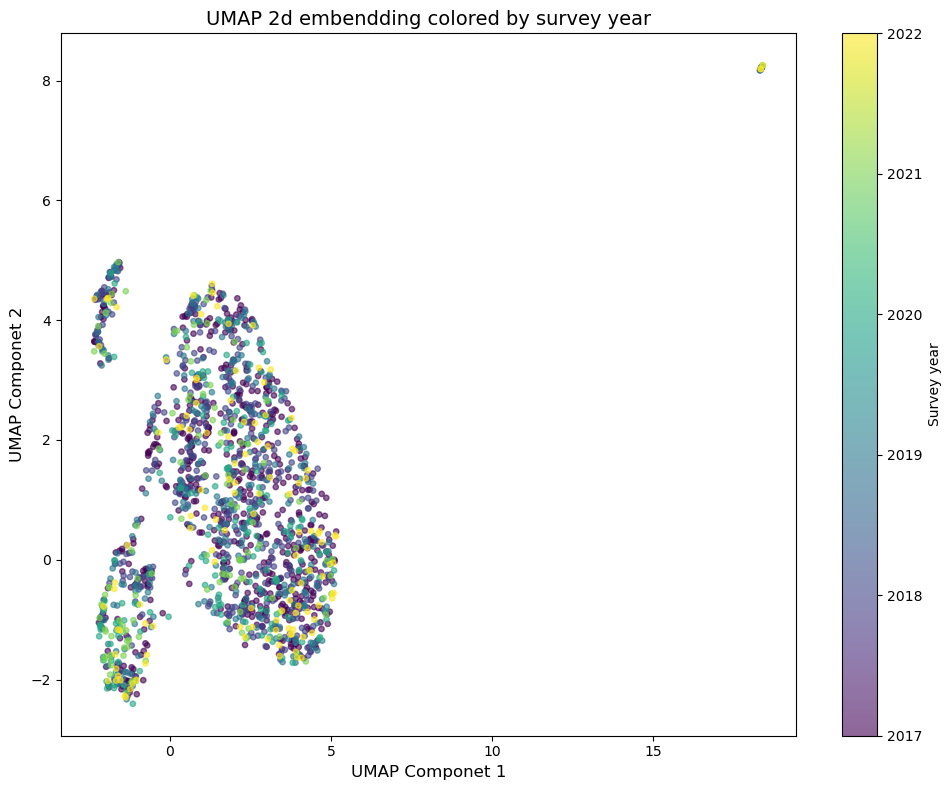

In [349]:
import umap

umap_model = umap.UMAP(
    n_components=2, # Numbers of components , 2 dimensions
    n_neighbors=15, # Controls the balance between local and global structure
    min_dist=0.1, # Controls how tightly points closer in the 2D space
    metric='euclidean', # Euclidean distance is appropriate after standardisation.
    random_state=42
)
# UMAP constructs a high-dimensional neighbourhood graph
# and project it into 2D
X_umap = umap_model.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10,8))
scatter = ax.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=years_labels,
    cmap='viridis',
    alpha=0.6,
    s=15
)
cbar = plt.colorbar(scatter)
cbar.set_label('Survey year')

ax.set_xlabel('UMAP Componet 1', fontsize=12)
ax.set_ylabel('UMAP Componet 2', fontsize=12)
ax.set_title('UMAP 2d embendding colored by survey year', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/11_UMAP_2d_by_year.png",dpi=150, bbox_inches='tight')
plt.show()

In [350]:
# Control of isolated points
np.where(X_umap[:,0] > 15)

(array([ 106,  121,  260,  284,  398,  468,  617,  822, 1011, 1044, 1056,
        1090, 1248, 1269, 1272, 1331, 1497, 1595, 1636, 1699]),)

In [351]:
df_master.iloc[[106,  121,  260,  284,  398,  468,  617,  822, 1011, 1044, 1056,
        1090, 1248, 1269, 1272, 1331, 1497, 1595, 1636, 1699]]

,Are you openly identified at work as a person with a mental health issue?,Are you self-employed?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health disorders and how to seek help?,Do you currently have a mental health disorder?,Do you have a family history of mental illness?,Do you have previous employers?,Do you know the options for mental health care available under your employer-provided health coverage?,Does your employer offer resources to learn more about mental health disorders and options for seeking help?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",...,Would you feel more comfortable talking to your coworkers about your physical health or your mental health?,Would you have been willing to discuss your mental health with your coworkers at previous employers?,Would you have been willing to discuss your mental health with your direct supervisor(s)?,Would you have felt more comfortable talking to your previous employer about your physical health or your mental health?,survey_year,covid_period,gender_Female,gender_Male,gender_Other/Non-binary,gender_Prefer not to say
106,0.0,0,0.0,0.0,1,2,1,1.0,1.0,1.0,...,1.0,1.0,1.0,0.0,2017,Pre-COVID,0,0,0,1
121,0.0,0,0.0,0.0,3,2,1,1.0,0.0,0.0,...,1.0,2.0,1.0,0.0,2017,Pre-COVID,0,0,0,1
260,0.0,0,0.0,0.0,3,2,0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,2017,Pre-COVID,0,0,0,1
284,0.0,0,0.0,0.0,2,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2017,Pre-COVID,0,0,0,1
398,0.0,0,1.0,1.0,3,0,1,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,2017,Pre-COVID,0,0,0,1
468,0.0,0,0.0,0.0,2,1,1,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,2017,Pre-COVID,0,0,0,1
617,1.0,0,0.0,0.0,2,1,1,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,2017,Pre-COVID,0,0,0,1
822,0.0,0,1.0,0.0,2,2,1,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,2018,Pre-COVID,0,0,0,1
1011,0.0,0,0.0,0.0,0,0,1,0.0,1.0,1.0,...,1.0,1.0,1.0,0.0,2019,Pre-COVID,0,0,0,1
1044,0.0,0,1.0,1.0,0,1,1,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,2019,Pre-COVID,0,0,0,1


While analysing the outliers, I noticed that they all belonged to the same gender field; I prefer not to say. After careful consideration of my research question and how this field would impact my model, I decided to eliminate the gender field from the gender-friendly model, focusing on other fields related to mental health and technology.

In [352]:
outlier_idx = np.where(X_umap[:,0]>16)[0]
df_master.iloc[outlier_idx]['gender_Prefer not to say'].mean()

np.float64(1.0)

### Outlier inspection
In the initial UMAP projection, a small group of points appeared separated from the main structure. After inspecting these observations, I found that they were all associated with the gender_Prefer not to say category.

Since this is a relatively rare domegraphic category, its one-hot encoding combined with feature standardisation may increase distances in the embedding space. As a result, the separation observed in UMAP seems to be driven by gender rather than mental health attitudes.

Because the aim of this study is to identify attitudinal mental health profiles, gender variables are removed form the feature matrix in teh next step. A new UMAP projection is therefore computed without gender indicators.

In [353]:
# Remove gender variables from feature matrix
gender_cols = [c for c in X.columns if c.startswith("gender_")]

X_no_gender = X.drop(columns=gender_cols)

print("Original shape:", X.shape)
print("Without gender:", X_no_gender.shape)


Original shape: (1701, 45)
Without gender: (1701, 41)


In [354]:
scaler = StandardScaler()
X_scaled_no_gender = scaler.fit_transform(X_no_gender)

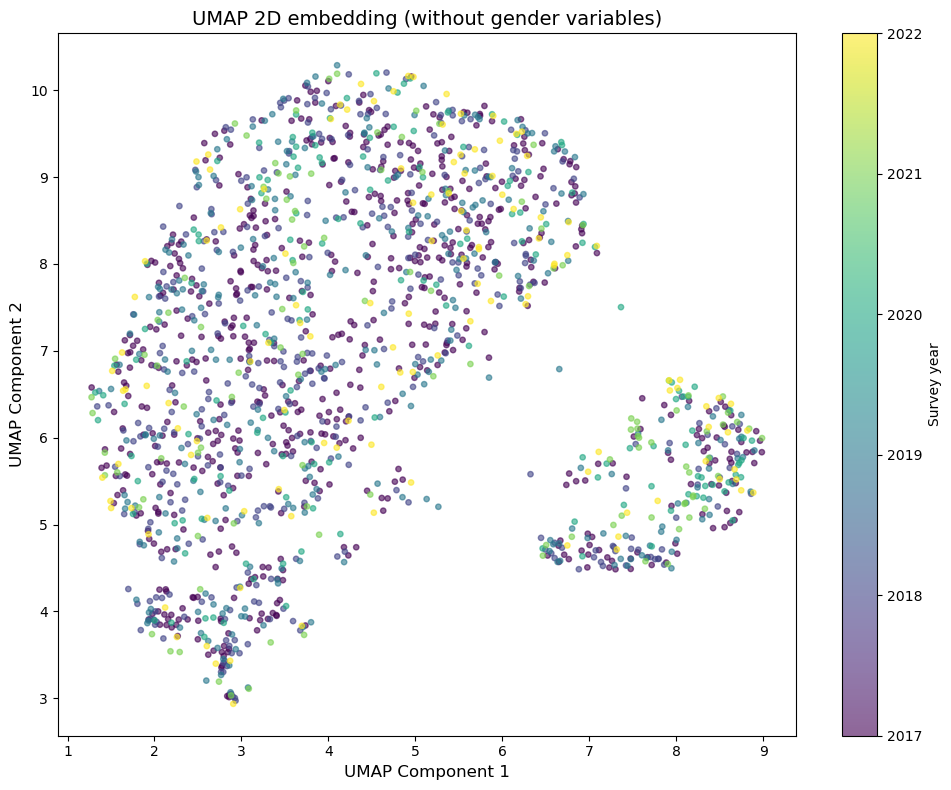

In [355]:
X_umap_no_gender = umap_model.fit_transform(X_scaled_no_gender)

fig, ax = plt.subplots(figsize=(10,8))

scatter = ax.scatter(
    X_umap_no_gender[:,0],
    X_umap_no_gender[:,1],
    c=years_labels,
    cmap='viridis',
    alpha=0.6,
    s=15
)

cbar = plt.colorbar(scatter)
cbar.set_label('Survey year')

ax.set_xlabel('UMAP Component 1', fontsize=12)
ax.set_ylabel('UMAP Component 2', fontsize=12)
ax.set_title('UMAP 2D embedding (without gender variables)', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/12_UMAP_2d_no_gender.png", dpi=150, bbox_inches='tight')
plt.show()

After removing gender variables from the feature matrix, the UMAP changes substantially. The previously isolated group is no longer strongly separated, suggesting that the earlier separation was largely driven by a rare demographic category rather then attitudinal structure.

In this embedding, a dominant central region is visible, alogn with at least one smaller but clearly subgroup. This indicates the possible precence of two to three underlying attitudinal configurations.

Survey years remain largely overlapping across regions, suggesting that mental health attitudes are not fully determined by time period alone.

### Dimension Classification (Mental Health vs Workplace/Tech)

Before clustering, I classify the features into conceptual dimensions, mainly mental-ehalth related variables and workplace/tech-related variables. This step improves interpretability after identifying clusters, I can understand whether patterns are driven more by personal mental-health or by organisational context. The classification is therfore used as an analysis for reading cluster profiles.

In [356]:
# Dimension calssification
feature_cols = X_no_gender.columns.tolist()

mental_keywords =[
    "mental", "mental health", "treatment", "family history", "seek help", "willing", "comfortable", "discussed your mental health"
]
tech_work_keywords =[
    "employer","workplace","company","organisation","tech","coworker","supervisor","benefits","resources"
]

mental_cols =[]
tech_work_cols =[]

for col in feature_cols:
    c = col.lower()

    if any(k in c for k in mental_keywords):
        mental_cols.append(col)
    elif any(k in c for k in tech_work_keywords):
        tech_work_cols.append(col)
other_cols = [ c for c in feature_cols if c not in mental_cols + tech_work_cols]

print("Dimension classification summary")
print(f"Total features: {len(feature_cols)}")
print(f"Mental-health features: {len(mental_cols)}")
print(f"Tech/workplace features: {len(tech_work_cols)}")
print(f"Other features: {len(other_cols)}")

# Create separate dataframes
df_mental = df_master[mental_cols].copy()
df_tech_work =df_master[tech_work_cols].copy()
df_other = df_master[other_cols].copy

Dimension classification summary
Total features: 41
Mental-health features: 32
Tech/workplace features: 7
Other features: 2


In [357]:
print(mental_cols[:5])
print(tech_work_cols[:5])
print(other_cols[:5])

['Are you openly identified at work as a person with a mental health issue?', 'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?', 'Did your previous employers provide resources to learn more about mental health disorders and how to seek help?', 'Do you currently have a mental health disorder?', 'Do you have a family history of mental illness?']
['Do you have previous employers?', 'How many employees does your company or organization have?', 'Is your employer primarily a tech company/organization?', 'Is your primary role within your company related to tech/IT?', 'Overall, how much importance did your previous employer place on physical health?']
['Are you self-employed?', 'What is your age?']


# Phase 5: Clustering Analysis

This phase is the core of my project. Here, I identify latent respondent profiles using unsupervised clustering on the final standardised feature matrix, excluding gender variables.

In the previous phases, I prepared and cleaned the OSMI dataset, explored trends over time, and used PCA/UMAP to visualise the structure of the data. In this phase, I move from visual exploration to formal profile detection. The objective is to group respondents with similar attitudes and experiences related to mental health and workplace context.

I use clustering to answer the central research goal of this project: understanding whether meaningful and interpretable respondent profiles emerge from the data, and how these profiles differ across key dimensions.

To support interpretation, I first organised variables into conceptual dimensions (mental-health related and workplace/tech related). After clustering, these dimensions are used to read and explain the profiles, rather than reporting clusters as purely numeric outputs.

The workflow for this phase is:
1. Fit K-Means models with different values of \(k\).
2. Evaluate model quality using silhouette score.
3. Select the most suitable number of clusters.
4. Assign cluster labels to respondents.
5. Interpret and compare clusters using the defined dimensions.

## Cluster Without Gender

c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

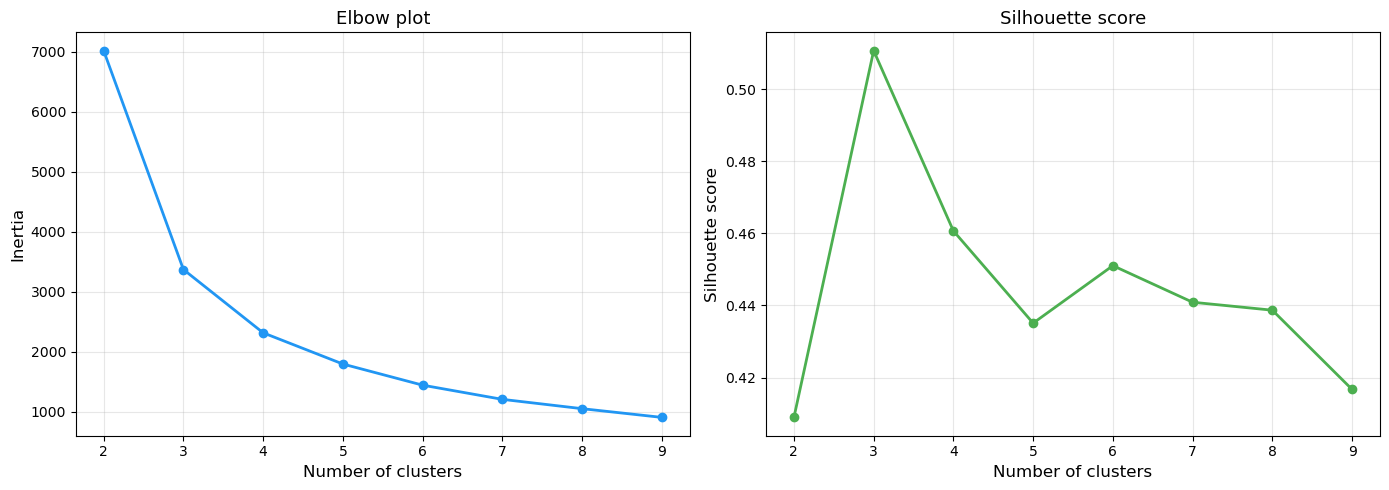


Best K Silhouette: 3 (score: 0.511)


In [394]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# I am going to use the final matrix without gender
X_cluster_no_gender = X_umap_no_gender[:,:2] #  2 dimensions

k_range = range(2, 10) # try 2 to 9 clusters
inertias = []
silhouettes =[]

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_cluster_no_gender)
  inertias.append(kmeans.inertia_)
  silhouettes.append(silhouette_score(X_cluster_no_gender, labels))

best_k_no_gender = list(k_range)[np.argmax(silhouettes)]
best_sil_no_gender = max(silhouettes)

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Elbow plot
axes[0].plot(k_range,inertias, 'o-', color='#2196F3' , linewidth=2)
axes[0].set_xlabel('Number of clusters', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow plot', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouettes, 'o-', color='#4CAF50', linewidth=2)
axes[1].set_xlabel('Number of clusters', fontsize=12)
axes[1].set_ylabel('Silhouette score', fontsize=12)
axes[1].set_title('Silhouette score', fontsize=13)
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/13_cluster_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBest K Silhouette: {best_k_no_gender} (score: {best_sil_no_gender:.3f})")

In [359]:
X_cluster_no_gender.shape

(1701, 2)

## Cluster With gender

c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

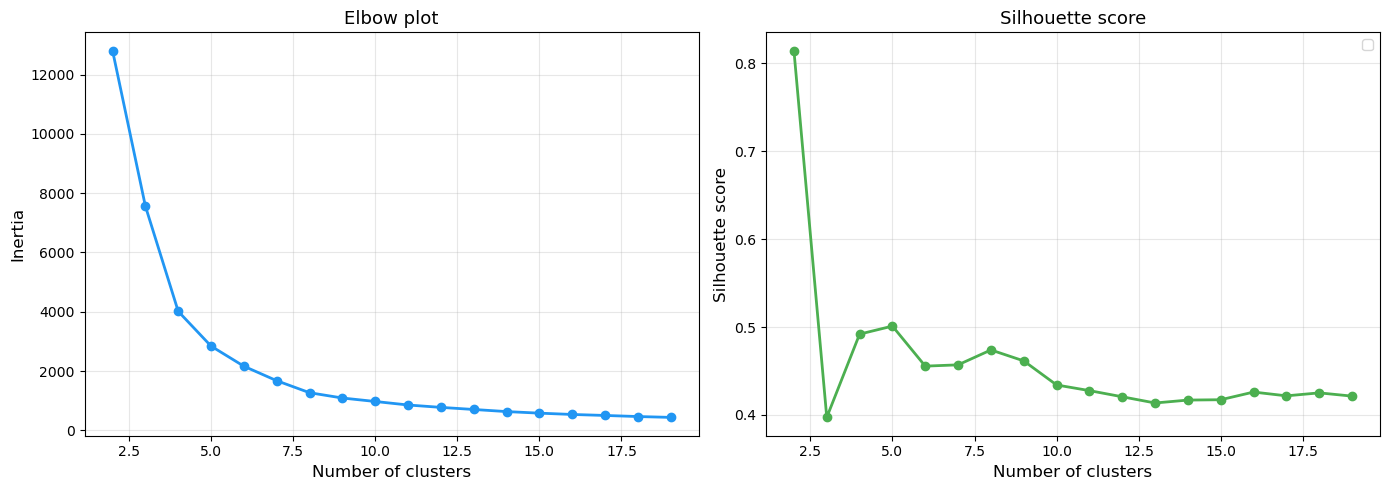


Best K Silhouette: 5 (score: 0.814)


In [390]:
# I am going to use uhe X_scaled with gender
X_cluster_gender = X_umap[:,:2]

k_range = range(2, 20) # try 2 to 19 clusters
inertias = []
silhouettes =[]

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(X_cluster_gender)
  inertias.append(kmeans.inertia_)
  silhouettes.append(silhouette_score(X_cluster_gender, labels))

best_k_gender = list(k_range)[1 + np.argmax(silhouettes[1:])] # skip k=2 for silhouette
best_sil = max(silhouettes)

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Elbow plot
axes[0].plot(k_range,inertias, 'o-', color='#2196F3' , linewidth=2)
axes[0].set_xlabel('Number of clusters', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow plot', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(k_range, silhouettes, 'o-', color='#4CAF50', linewidth=2)
axes[1].set_xlabel('Number of clusters', fontsize=12)
axes[1].set_ylabel('Silhouette score', fontsize=12)
axes[1].set_title('Silhouette score', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "/13_cluster_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBest K Silhouette: {best_k_gender} (score: {best_sil:.3f})")

In [391]:
X_cluster_gender.shape

(1701, 2)

The silhouette score measures how well separated the clusters are. Higher values indicate clearer cluster structures, while lower values suggest overlapping groups, which is common in social survey data.

c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Text(0, 0.5, 'UMAP Component 2')

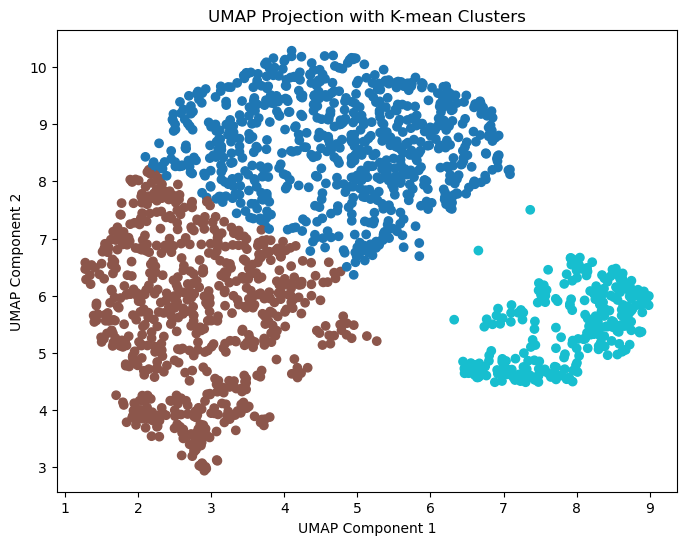

In [395]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_cluster_no_gender)
plt.figure(figsize=(8,6))
plt.savefig(OUTPUT_PATH + "/14_cluster_without_gender.png", dpi=150, bbox_inches='tight')
plt.scatter(X_umap_no_gender[:,0], X_umap_no_gender[:,1], c=labels, cmap='tab10')
plt.title("UMAP Projection with K-mean Clusters")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

The UMAP visualisation coloured by the K-means labels provides a simple visual rapresentation fo the clustering structure. Three main groups of respondent can be obeserved, although the boundary between them is not perfectly separated and some overlap between points. This is expected as the UMAP project high-dimensional feature space into two dimensions this may introduce distortions in distances.

c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Text(0, 0.5, 'UMAP Component 2')

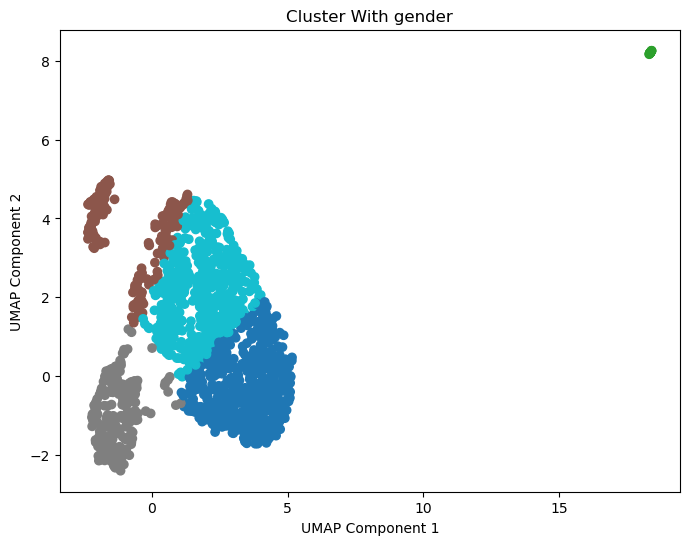

In [396]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_cluster_gender)
plt.figure(figsize=(8,6))
plt.savefig(OUTPUT_PATH + "/14_cluster_with_gender.png", dpi=150, bbox_inches='tight')
plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap='tab10')
plt.title("Cluster With gender")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

## Cluster Overview

In [397]:
# Use best_k, but cap at reasonable number
print(f"\nUsing K={best_k_no_gender} clusters")

kmeans_final = KMeans(n_clusters=best_k_no_gender, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled_no_gender)
df_master['cluster'] = cluster_labels

print(f"\nCluster sizes:")
print(f"Respondant {df_master['cluster'].value_counts().sort_index()}")
print(f"Total respondents: {df_master['cluster'].value_counts().sum()}")


Using K=3 clusters

Cluster sizes:
Respondant cluster
0    618
1    512
2    571
Name: count, dtype: int64
Total respondents: 1701


c:\Users\Tommaso\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


In [398]:
cols_to_drop = ['survey_year'] + [c for c in df_master.columns if c.startswith('gender_')]

cluster_summary = (
    df_master
    .drop(columns=cols_to_drop)
    .groupby('cluster')
    .mean(numeric_only=True)
)

cluster_summary

,Are you openly identified at work as a person with a mental health issue?,Are you self-employed?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health disorders and how to seek help?,Do you currently have a mental health disorder?,Do you have a family history of mental illness?,Do you have previous employers?,Do you know the options for mental health care available under your employer-provided health coverage?,Does your employer offer resources to learn more about mental health disorders and options for seeking help?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",...,Were you aware of the options for mental health care provided by your previous employers?,What is your age?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Would you bring up your mental health with a potential employer in an interview?,Would you feel comfortable discussing a mental health issue with your coworkers?,Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?,Would you feel more comfortable talking to your coworkers about your physical health or your mental health?,Would you have been willing to discuss your mental health with your coworkers at previous employers?,Would you have been willing to discuss your mental health with your direct supervisor(s)?,Would you have felt more comfortable talking to your previous employer about your physical health or your mental health?
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.019417,0.0,0.207120,0.257282,0.459547,0.556634,0.750809,0.258900,0.254045,0.260518,...,1.404531,34.412621,0.954693,0.490291,1.027508,1.148867,0.355987,0.766990,0.797735,0.244337
1,0.033203,0.0,0.160156,0.261719,2.292969,1.285156,0.884766,0.380859,0.246094,0.218750,...,1.474609,35.222656,0.712891,0.121094,0.533203,0.490234,0.121094,0.480469,0.445312,0.150391
2,0.306480,0.0,0.373030,0.537653,2.511384,1.537653,0.882662,0.628722,0.481611,0.458844,...,1.761821,34.852890,0.919440,0.502627,1.502627,1.513135,0.530648,0.968476,0.942207,0.266200


In [399]:
pd.crosstab(df_master['cluster'], df_master['gender_Male'])

gender_Male,0,1
cluster,,
0,164,454
1,204,308
2,249,322


In [400]:
df_master.groupby('cluster')[['gender_Female','gender_Male']].mean()

,gender_Female,gender_Male
cluster,,
0,0.226537,0.734628
1,0.328125,0.601562
2,0.336252,0.563923


After determining the optimal number of clusters using silhouette analysis, the final K-means model was fitted on the standardised feature matrix excluding gender variables. Each respondent was then assigned to one of the two clusters and the cluster labels were added to the master dataset.

To understand the structure of the clusters, I first examined the size of each group, which showed a relatively balanced distribution of respondents across the two clusters. Next, I analysed the average value of each variable within each cluster in order to identify which mental health attitudes and workplace-related factors differed the most between the groups.

Finally, although gender variables were excluded from the clustering process to avoid introducing demographic bias, they were reintroduced in a separate analysis to examine how gender was distributed across the clusters. This step helped assess whether gender composition differed between the identified groups.

## Cluster Profile Visualisation

To understand the characteristics of the identified clusters, the average values of the survey variables were visualised and compared across the three groups. Since the dataset contains a large number of variables related to mental health experiences, workplace environments and disclosure attitudes, visualisation helps highlight the most relevant differences between clusters.

To facilitate interpretation, the survey variables were grouped into two main conceptual categories defined in the previous section: mental health related factors and workplace or organisational support factors.

This grouping allows a more structured interpretation of the clusters by highlighting whether the differences between respondent groups are primarily associated with personal mental health experiences or with workplace environments.



### Mental health related variables



In [401]:
# cluster variable mean
mental_cluster = df_master.groupby('cluster')[mental_cols].mean()

# Only the absolute number of the difference between clusters
mental_diff = (mental_cluster.loc[0] - mental_cluster.loc[1]).abs()

# This allow me to select only the top 10 questions
top10_mental = mental_diff.sort_values(ascending=False).head(10).index.tolist()

print("Top 10 mental health variables:")
for i, col in enumerate(top10_mental, 1):
    print(f"Q{i}: {col}")

Top 10 mental health variables:
Q1: If you have a mental health disorder, how often do you feel that it interferes with your work when NOT being treated effectively (i.e., when you are experiencing symptoms)?
Q2: Overall, how much importance does your employer place on mental health?
Q3: Do you currently have a mental health disorder?
Q4: Overall, how much importance did your previous employer place on mental health?
Q5: If you have a mental health disorder, how often do you feel that it interferes with your work when being treated effectively?
Q6: Have you had a mental health disorder in the past?
Q7: If a mental health issue prompted you to request a medical leave from work, how easy or difficult would it be to ask for that leave?
Q8: How willing would you be to share with friends and family that you have a mental illness?
Q9: Overall, how well do you think the tech industry supports employees with mental health issues?
Q10: Do you have a family history of mental illness?


The above cell is very relevant for the research as highlith the most relevant differences between clusters. The variables were ranked according to the absolute difference in theri average values across clusters. The top 10 variables with the largest differences were selected for visualisation.

In [403]:
# Top 10 variable sort in ascending order
top10_mental = mental_diff.sort_values(ascending=False).head(10)

# dataset
plot_data = df_master.groupby('cluster')[top10_mental.index].mean().T

# create mapping Q1, Q2... keeping the importance order
question_map = {col: f"Q{i+1}" for i, col in enumerate(top10_mental.index)}

plot_data.index = [question_map[col] for col in plot_data.index]

In [404]:
# Average values of other contextual variables by cluster
mental_cluster = df_master.groupby('cluster')[mental_cols].mean()

print("Average values of other variables by cluster:")
display(mental_cluster.round(2))

Average values of other variables by cluster:


,Are you openly identified at work as a person with a mental health issue?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health disorders and how to seek help?,Do you currently have a mental health disorder?,Do you have a family history of mental illness?,Do you know the options for mental health care available under your employer-provided health coverage?,Does your employer offer resources to learn more about mental health disorders and options for seeking help?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Have you ever discussed your mental health with coworkers?,Have you ever discussed your mental health with your employer?,...,"Overall, how well do you think the tech industry supports employees with mental health issues?",Were you aware of the options for mental health care provided by your previous employers?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Would you bring up your mental health with a potential employer in an interview?,Would you feel comfortable discussing a mental health issue with your coworkers?,Would you feel comfortable discussing a mental health issue with your direct supervisor(s)?,Would you feel more comfortable talking to your coworkers about your physical health or your mental health?,Would you have been willing to discuss your mental health with your coworkers at previous employers?,Would you have been willing to discuss your mental health with your direct supervisor(s)?,Would you have felt more comfortable talking to your previous employer about your physical health or your mental health?
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.02,0.21,0.26,0.46,0.56,0.26,0.25,0.26,0.20,0.13,...,2.84,1.40,0.95,0.49,1.03,1.15,0.36,0.77,0.80,0.24
1,0.03,0.16,0.26,2.29,1.29,0.38,0.25,0.22,0.27,0.17,...,2.11,1.47,0.71,0.12,0.53,0.49,0.12,0.48,0.45,0.15
2,0.31,0.37,0.54,2.51,1.54,0.63,0.48,0.46,0.84,0.62,...,2.83,1.76,0.92,0.50,1.50,1.51,0.53,0.97,0.94,0.27


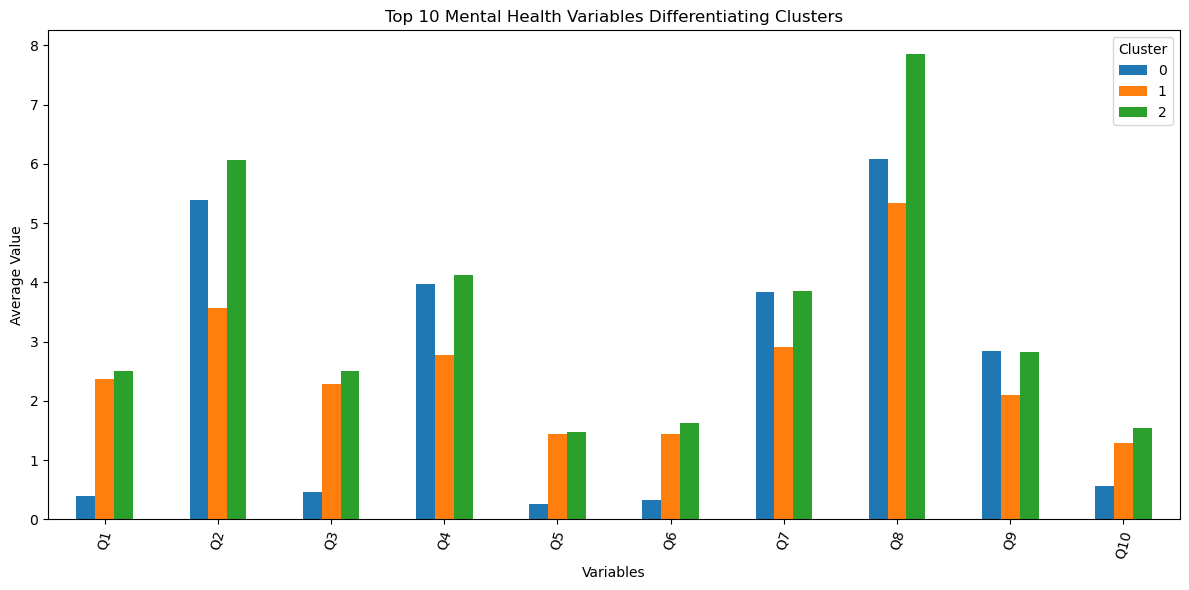

In [405]:
plot_data.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Mental Health Variables Differentiating Clusters")
plt.ylabel("Average Value")
plt.xlabel("Variables")

plt.xticks(rotation=75)
plt.legend(title="Cluster")

plt.savefig(OUTPUT_PATH + "/15_Top10_MentalHealth.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

To interpret the identified cluster, the average values of the mental-health related survey variables were compared across the three groups. The variable were ranked according to the absolute difference between cluster means, and the ten variables with the largest differences were selected for visualisation.

The results is very interesting as Cluster 2 reports higher average values across most mental-health related questions. In particulare, the largest difference are observed in variable related to personal experience with mental health conditions and willingness to disclose. This suggests that Cluster 1 rapresents respondents with a higher level of exposure to mental health challenges, while Cluster 0 appears to include individuals with lower experience with such issues.

### Workplace and organisational variables

In [372]:
# cluster variable mean
workplace_cluster = df_master.groupby('cluster')[tech_work_cols].mean()

# Only the absolute number of the difference between clusters
workplace_diff = (workplace_cluster.loc[0] - workplace_cluster.loc[1]).abs()

# This allow me to select only the top 10 questions
top10_tech_work_cols = workplace_diff.sort_values(ascending=False).head(10).index.tolist()

print("Top 10 workplace variables:")
for i, col in enumerate(top10_tech_work_cols, 1):
    print(f"Q{i}: {col}")

Top 10 workplace variables:
Q1: Overall, how much importance did your previous employer place on physical health?
Q2: How many employees does your company or organization have?
Q3: Overall, how much importance does your employer place on physical health?
Q4: Was your employer primarily a tech company/organization?
Q5: Do you have previous employers?
Q6: Is your primary role within your company related to tech/IT?
Q7: Is your employer primarily a tech company/organization?


The above cell identifies the top workplace and organisational variables that differ the most between the clusters. In this case, the number of variables related to workplace and organisational aspects is limited to seven. Despite the smaller number of features compared with the mental-health related variables, these questions remain important for understanding the contextual environment in which respondents work.

By examining the differences in the average values of these variables across clusters, it becomes possible to explore how workplace characteristics and organisational contexts may contribute to the formation of different respondent profiles. This analysis therefore complements the previous mental-health related investigation and helps assess whether the identified clusters are influenced not only by personal mental-health experiences but also by workplace conditions and organisational factors.

In [406]:
# Top 10 variable sort in ascending order
top10_tech_work_cols = workplace_diff.sort_values(ascending=False).head(10)

# dataset
plot_data = df_master.groupby('cluster')[top10_tech_work_cols.index].mean().T

# create mapping Q1, Q2... keeping the importance order
question_map = {col: f"Q{i+1}" for i, col in enumerate(top10_tech_work_cols.index)}

plot_data.index = [question_map[col] for col in plot_data.index]

In [407]:
# Average values of other contextual variables by cluster
workplace_cluster = df_master.groupby('cluster')[tech_work_cols].mean()

print("Average values of other variables by cluster:")
display(workplace_cluster.round(2))

Average values of other variables by cluster:


,Do you have previous employers?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,"Overall, how much importance did your previous employer place on physical health?","Overall, how much importance does your employer place on physical health?",Was your employer primarily a tech company/organization?
cluster,,,,,,,
0,0.75,3.93,0.75,0.94,5.32,6.47,0.79
1,0.88,4.42,0.61,0.95,4.92,5.57,0.67
2,0.88,4.21,0.80,0.90,5.83,6.81,0.67


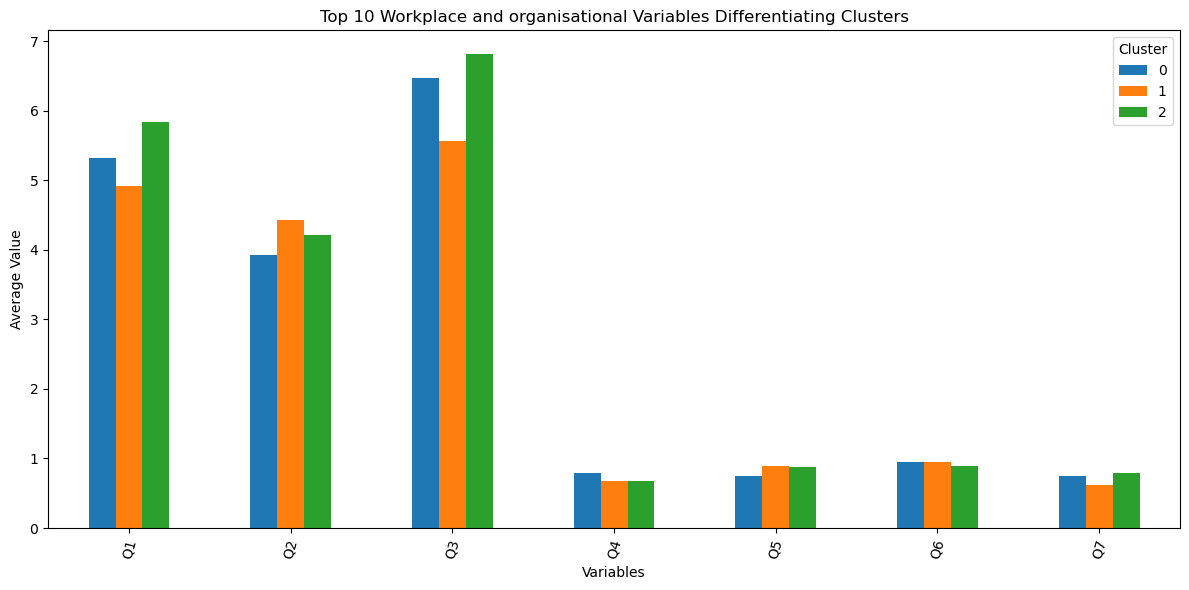

In [408]:
plot_data.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Workplace and organisational Variables Differentiating Clusters")
plt.ylabel("Average Value")
plt.xlabel("Variables")

plt.xticks(rotation=75)
plt.legend(title="Cluster")

plt.savefig(OUTPUT_PATH + "/16_Top10_Workplace.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

The bar plot provides a comparison of the average values of the workplace and organisational variables across the three clusters. Overall, the differences between clusters appear relatively small compared with those observed for the mental-health related variables. This suggests that the primary distinction between the identified respondent groups is more strongly associated with personal experiences and attitudes towards mental health rather than with organisational context.

The first three variables display noticeably higher average values than the others, as they relate to broader organisational characteristics such as company size and the perceived importance of health within the workplace. However, the similarity between clusters across most workplace variables indicates that organisational factors may play a secondary role in differentiating the respondent profiles identified in this study.

### Other Variables

A small number of additional variables, such as age, were also examined to provide contextual infomation about the clusters. Given their limited number they are discussed briefly rather than visualised.

In [409]:
# cluster variable mean
other_cluster = df_master.groupby('cluster')[other_cols].mean()

# Only the absolute number of the difference between clusters
other_diff = (other_cluster.loc[0] - other_cluster.loc[1]).abs()

# This allow me to select only the top 5 questions
top5_other_cols= other_diff.sort_values(ascending=False).head(5).index.tolist()

print("Top 10 workplace variables:")
for i, col in enumerate(top5_other_cols, 1):
    print(f"Q{i}: {col}")

Top 10 workplace variables:
Q1: What is your age?
Q2: Are you self-employed?


In [410]:
# Average values of other contextual variables by cluster
other_cluster = df_master.groupby('cluster')[other_cols].mean()

print("Average values of other variables by cluster:")
display(other_cluster.round(2))

Average values of other variables by cluster:


,Are you self-employed?,What is your age?
cluster,,
0,0.0,34.41
1,0.0,35.22
2,0.0,34.85


## Cluster Interpretation



#### Discussion of the main differences

The previous analysis showed the variables that best distinguish the three clusters. By looking at patterns related to mental health, workplace features, and other background factors, we can describe the clusters as three different groups of respondents.

- **Cluster 1 (lower support and openness)** tends to have lower average scores on several mental-health-related variables, especially those linked to employer support and willingness to talk about mental health (e.g. Q2 and Q7 in Figure 13). Respondents in this group appear less likely to perceive strong organisational support and may find it more difficult to discuss or address mental health issues at work.

- **Cluster 2 (higher awareness and organisational engagement)** shows higher scores for most mental-health variables, particularly in items related to awareness, perceived importance and openness (e.g. Q2, Q4 and Q8). People in this group are more likely to report mental health difficulties, to value mental health in the workplace and to feel able to talk about these issues. This cluster therefore represents workers who both face more challenges and show higher levels of awareness and engagement around mental health.

- **Cluster 0 (intermediate profile)** generally displays values between the other two groups. Respondents in this cluster report moderate levels of awareness and support, without the clearly negative pattern of Cluster 1 or the clearly positive pattern of Cluster 2. This suggests a more “mixed” profile, where attitudes and experiences are neither strongly unfavourable nor strongly favourable.

Regarding workplace and organisational factors, the three clusters show some differences in perceived employer support, which is higher in Cluster 2 and lower in Cluster 1, while Cluster 0 again lies in between. However, other contextual aspects, such as role type or company size, appear less influential in defining the cluster structure. Similarly, demographic variables like age or self-employment status do not differ markedly across clusters and do not seem to explain the observed patterns.

Overall, the results suggest that the clusters are mainly distinguished by mental-health experiences, perceived organisational support and openness to discussing these issues, rather than by structural workplace characteristics or basic demographics.

## Cluster distribution across COVID periods

The COVID-19 pandemic had a major impact on working practices, including the rapid adoption of remote work and changes in organisational environments. To examine whether these changes influenced the mental health profiles indentified in this study, the dataset was divided into tree periods: pre-COVID (2017-2019), during-COVID (2020-2021), and post-COVID(2022). The distribution of clusters across these periods was then analysed to explore the rlative size of the identified profiles changed over time.

In [411]:
covid_cluster = pd.crosstab(
    df_master["covid_period"],
    df_master["cluster"],
    normalize="index"
) * 100

covid_cluster.round(2)
covid_cluster = covid_cluster.loc[
    ["Pre-COVID", "During-COVID", "Post-COVID"]
]

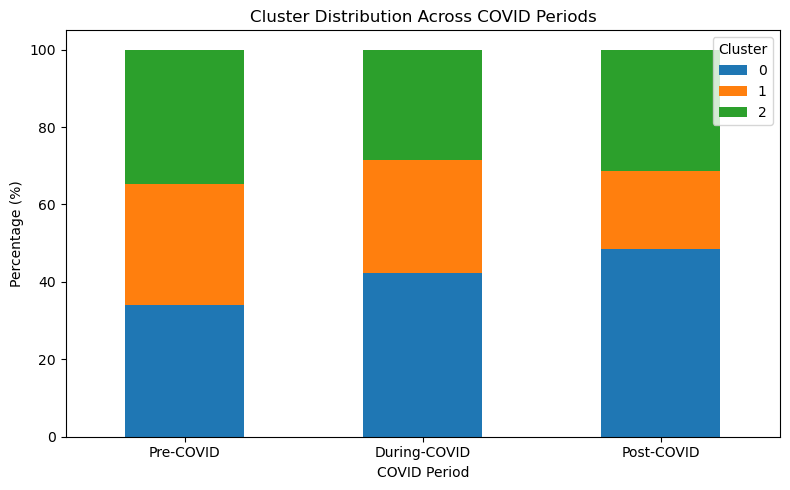

In [412]:
covid_cluster.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Cluster Distribution Across COVID Periods")
plt.ylabel("Percentage (%)")
plt.xlabel("COVID Period")
plt.legend(title="Cluster")
plt.xticks(rotation=0)

plt.savefig(OUTPUT_PATH + "/17_Cluster_distribution_across_Covid_Periods.png", dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

The distribution of clusters across the three COVID periods shows some variation in the relative size of the identified profiles. Before the pandemic, the sample is relatively balanced, with Cluster 1 representing the largest group of respondents. During the COVID period, however, the distribution shifts and Cluster 0 becomes the dominant profile, while the share of Cluster 1 decreases.

This shift may reflect broader changes in working practices introduced during the pandemic, such as increased remote work and a stronger focus on employee wellbeing. Although all three clusters remain present across all periods, the results suggest that the relative prevalence of the identified mental-health profiles varies over time.

In the post-COVID period, Cluster 0 continues to represent the largest share of respondents, while Cluster 2 remains relatively stable and Cluster 1 remains smaller than in the pre-COVID years. This pattern indicates that some of the changes observed during the pandemic may persist even after a partial return to pre-pandemic working conditions.

# PHASE 6: Statistical testing

To assess the differences across COVID periods were statistically meaningful, a Chi-sqare test of independence was conducted. This test is used to determine whether two categorical variable are associated with each other.

In this analysis, the Chi-square test was applied to examine whether the distribution of cluster membership differed signficaltly across the theree COVID periods.

The contingency table was constructed usign the cluster labels and the COVID periods categoris.

In [413]:
from scipy.stats import chi2_contingency

# contingency table
table = pd.crosstab(df_master['covid_period'], df_master['cluster'])

print(table)

# chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p) # value x 10 to the power of -5

cluster         0    1    2
covid_period               
During-COVID  114   78   77
Post-COVID     60   25   39
Pre-COVID     444  409  455
Chi-square: 17.192737677904606
p-value: 0.0017731741063611


The Chi-square statistic measures how different the observed data are from the values that would be expected if there were no relationship between the variables. A higher Chi-square value indicates a stronger difference between the observed and expected frequencies.

The p-value represents the probability that the observed difference occurred purely by chance. In this case, the p-value is extremely small (p < 0.001), indicating that the probability of the difference being random is very low.

These results suggest that the distribution of clusters is associated with the COVID period. In other words, the mental-health attitude profiles vary across the pre-COVID, during-COVID and post-COVID phases, indicating that the pandemic period may have influenced the prevalence of these profiles.

# PHASE 7: Results Summary & Export

In [414]:
print("FINAL RESULTS SUMMARY")
print("======================================")

print("Dataset:")
print(f"Total respondents analysed: {len(df_master)}")

print("\nClustering:")
print("Number of clusters identified:", df_master['cluster'].nunique())

print("\nCOVID analysis:")
print("Chi-square test shows a significant association between COVID period and cluster membership.")
print(f"Chi-square statistic: {chi2:.2f}, p-value: {p:.4f}")

print("\nMain findings:")
print("Three distinct mental health attitude profiles were identified among technology workers.")
print("These profiles differ primarily in mental health experiences, perceived organisational support,")
print("and willingness to discuss mental health issues, while demographic and job-related factors play a smaller role.")
print("Their distribution changes significantly across pre-COVID, during-COVID and post-COVID periods,")
print("suggesting that the COVID-19 context influenced the prevalence of these profiles.")

FINAL RESULTS SUMMARY
Dataset:
Total respondents analysed: 1701

Clustering:
Number of clusters identified: 3

COVID analysis:
Chi-square test shows a significant association between COVID period and cluster membership.
Chi-square statistic: 17.19, p-value: 0.0018

Main findings:
Three distinct mental health attitude profiles were identified among technology workers.
These profiles differ primarily in mental health experiences, perceived organisational support,
and willingness to discuss mental health issues, while demographic and job-related factors play a smaller role.
Their distribution changes significantly across pre-COVID, during-COVID and post-COVID periods,
suggesting that the COVID-19 context influenced the prevalence of these profiles.


The analysis suggests that mental health attitude profiles exist among technology workers and that their distribution changed across COVID periods.